In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import pickle

from scipy.optimize import curve_fit

current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'

# Build the absolute path to ../functions
functions_path = os.path.abspath(os.path.join(current_dir, '../functions'))

# Add it to sys.path
sys.path.append(functions_path)

import parse_data 
import cigar as cig

from tqdm import tqdm


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


##  Signal time constants

In [2]:
# colors = ['royalblue', 'crimson', 'black', 'green', 'darkorange', 'brown', 'coral', 'indigo', 'magenta', 'blue']
# Wong (2011) colorblind-safe palette – 8 distinct colors
# Works for deuteranopia, protanopia, and tritanopia

# Grayscale palette – 10 shades from near-black to light gray
# Paired with distinct markers and line styles for full grayscale legibility
GS_COLORS = [
    '#000000',  # Black
    '#1a1a1a',  # Near black
    '#333333',  # Very dark gray
    '#4d4d4d',  # Dark gray
    '#666666',  # Medium dark gray
    '#808080',  # Medium gray
    '#999999',  # Medium light gray
    '#b3b3b3',  # Light gray
    '#cccccc',  # Very light gray
    '#e6e6e6',  # Near white (use only on dark backgrounds)
]

CB_COLORS = [
    '#000000',  # Black
    '#E69F00',  # Orange
    '#56B4E9',  # Sky blue
    '#009E73',  # Bluish green
    '#F0E442',  # Yellow
    '#0072B2',  # Blue
    '#D55E00',  # Vermillion
    '#CC79A7',  # Reddish purple
    '#994F00',  # Brown        
    '#006CD1',  # Cerulean     
]

colors = CB_COLORS

# Distinct markers and line styles for extra redundancy (grayscale-safe)
CB_MARKERS    = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
CB_LINESTYLES = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.', ':']


In [3]:


font_size = 20
# Configure matplotlib to use Computer Modern fonts and mathtext
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = font_size
     


In [4]:
base    = f"/home/marian/CIGAR_ANALYSIS/CIGAR/data"

##  Functions

In [5]:
def _rise_decay_normalised(t, t0, rise, decay):
    """Unit-area (1-exp)×exp pulse anchored at t0, zero for t < t0."""
    s = np.zeros_like(t, dtype=float)
    mask = t >= t0
    s[mask] = (1.0 - np.exp(-(t[mask]-t0) / rise)) * np.exp(-(t[mask]-t0) / decay)
    area = np.trapz(s, x=t)
    return s / (area if area != 0 else 1.0)



In [6]:
def ResponseSiPM(q_in_pes, t, t0, rise_time, decay_time, baseline=0.0):
    """
    SiPM single-PE pulse: area-normalised (1-exp)×exp, scaled by q_in_pes.
    rise_time and decay_time are free — fix them externally if needed.
    """
    return q_in_pes * _rise_decay_normalised(t, t0, rise_time, decay_time) + baseline

In [7]:
def _check_bounds(popt, bounds_ch, label, names):
    """
    Check if any fitted parameter landed within 1% of its hard bounds.
    Prints a warning for each parameter that is close to a bound.

    Parameters
    ----------
    popt      : array   fitted parameter values
    bounds_ch : tuple   (lower, upper) lists
    label     : str     identifier for the warning message (e.g. channel name)
    names     : list    parameter names, same length as popt
    """
    tol = 0.01
    for i, (p, lo, hi) in enumerate(zip(popt, bounds_ch[0], bounds_ch[1])):
        span = (hi - lo) if not np.isinf(hi) else None
        if span is not None:
            if np.abs(p - lo) < tol * span:
                print(f'  ⚠ [{label}] {names[i]:12s} hit lower bound: '
                      f'value={p:.4e}  lower={lo:.4e}')
            elif np.abs(p - hi) < tol * span:
                print(f'  ⚠ [{label}] {names[i]:12s} hit upper bound: '
                      f'value={p:.4e}  upper={hi:.4e}')
        else:
            # hi is inf — only check lower bound with relative tolerance
            if p > 0 and np.abs(p - lo) / p < tol:
                print(f'  ⚠ [{label}] {names[i]:12s} hit lower bound: '
                      f'value={p:.4e}  lower={lo:.4e}')

In [8]:
def _I(p, q, u):
    """
    I(p, q, u) = integral_0^u  exp(-p*s) * exp(-q*(u-s)) ds

    p = rate of the 'left'  factor in the integrand  (units: 1/s)
    q = rate of the 'right' factor in the integrand  (units: 1/s)
    u = shifted time from pulse onset  (units: s),  u >= 0

    Result:
        (exp(-p*u) - exp(-q*u)) / (q - p)   if p != q
        u * exp(-p*u)                         if p == q  (L'Hopital)
    """
    if np.abs(p - q) < 1e-30:
        return u * np.exp(-p * u)
    return (np.exp(-p * u) - np.exp(-q * u)) / (q - p)


In [9]:
def _conv_two_rise_decay(u, rise1, decay1, rise2, decay2):
    """
    Analytical convolution of two (1-exp)*exp pulses starting at u=0.

    Expanding f1 = exp(-a*s) - exp(-b*s)
    with  a = 1/decay1
          b = 1/rise1 + 1/decay1

    and f2 = exp(-c*(u-s)) - exp(-d*(u-s))
    with  c = 1/decay2
          d = 1/rise2 + 1/decay2

    gives 4 I() terms:
        h(u) = I(a,c,u) - I(a,d,u) - I(b,c,u) + I(b,d,u)
    """
    a = 1.0 / decay1
    b = 1.0 / rise1 + 1.0 / decay1
    c = 1.0 / decay2
    d = 1.0 / rise2 + 1.0 / decay2

    return _I(a,c,u) - _I(a,d,u) - _I(b,c,u) + _I(b,d,u)



In [10]:
def recombination_model(t, t0, tau_rec, Tr):
    """
    Recombination scintillation model (causal, no in-place mutation):
        (1 - exp(-u/tau_rec)) * (1 + u/Tr)^2    for u = t - t0 > 0
        0                                         otherwise
    """
    u    = t - t0
    mask = u > 0
    out  = np.zeros_like(t, dtype=float)
    out[mask] = (1.0 - np.exp(-u[mask] / tau_rec)) * (1.0 + u[mask] / Tr)**2
    return out

In [11]:
def CIGARResponse_analytical(t,
                             t0_ar,
                             A_singlet, rise_singlet, tau_singlet,
                             A_triplet, rise_triplet, tau_triplet,
                             A_rec, tau_rec, Tr,
                             delta_rec,
                             baseline=0.0):
    """
    CIGAR(t) = singlet branch + triplet branch + recombination branch + baseline

    SiPM shape is fixed: rise=1 ns, decay=64 ns (Suzuki values).
    Singlet, triplet rise and decay are FREE parameters.
    All convolution branches are area-normalised before scaling by amplitude,
    so A_singlet, A_triplet, A_rec are directly comparable physical amplitudes.

    Parameters
    ----------
    t0_ar       : float   onset of Ar scintillation [s]
    A_singlet   : float   singlet amplitude
    rise_singlet: float   singlet rise time [s]   (FREE)
    tau_singlet : float   singlet decay time [s]  (FREE)
    A_triplet   : float   triplet amplitude
    rise_triplet: float   triplet rise time [s]   (FREE)
    tau_triplet : float   triplet decay time [s]  (FREE)
    A_rec       : float   recombination amplitude
    tau_rec     : float   recombination time constant [s]
    Tr          : float   recombination characteristic time [s]
    delta_rec   : float   recombination onset delay after t0_ar [s]
    baseline    : float   DC offset
    """
    sipm_rise  = 1e-9    # fixed SiPM rise  [s]
    sipm_decay = 64e-9   # fixed SiPM decay [s]

    u    = t - t0_ar
    mask = u > 0

    # --- singlet branch ---
    h_singlet       = np.zeros_like(t, dtype=float)
    h_singlet[mask] = _conv_two_rise_decay(u[mask],
                                           rise_singlet, tau_singlet,
                                           sipm_rise, sipm_decay)
    area = np.trapz(h_singlet, x=t)
    if area > 0:
        h_singlet *= A_singlet / area

    # --- triplet branch ---
    h_triplet       = np.zeros_like(t, dtype=float)
    h_triplet[mask] = _conv_two_rise_decay(u[mask],
                                           rise_triplet, tau_triplet,
                                           sipm_rise, sipm_decay)
    area = np.trapz(h_triplet, x=t)
    if area > 0:
        h_triplet *= A_triplet / area

    # --- recombination branch (delayed, no convolution with SiPM) ---
    h_rec = A_rec * recombination_model(t, t0_ar + delta_rec, tau_rec, Tr)

    return baseline + h_singlet + h_triplet + h_rec

In [12]:
def fit_cigar_waveforms(runs_dict, base,
                        pretrigger_sample=125,
                        channels_to_show=None, invert=True,
                        p0_cigar=None, bounds_cigar=None,
                        colors=None, font_size=14, logscale=False):
    """
    Load CIGAR mean waveforms, overplot all runs, fit CIGARResponse_analytical.

    Model: singlet + triplet + recombination, SiPM shape fixed (1 ns / 64 ns).
    Singlet and triplet rise/decay are FREE parameters.

    Parameters
    ----------
    runs_dict         : dict {label: run_name_or_int}
    base              : str   base directory
    pretrigger_sample : int   sample index where pulse starts (default 125)
    channels_to_show  : list or None
    invert            : bool
    p0_cigar          : dict {ch: [t0_ar, A_singlet, rise_singlet, tau_singlet,
                                          A_triplet, rise_triplet, tau_triplet,
                                          A_rec, tau_rec, Tr,
                                          delta_rec]} or None (auto)
    bounds_cigar      : dict {ch: (lower_list, upper_list)} or None (auto)
    colors            : list of colours — use CB_COLORS or GS_COLORS, branch
                        colors are derived automatically from colors[1], [2], [3]
    font_size         : int
    logscale          : bool

    Returns
    -------
    fig          : Figure
    axs          : 2×2 array of Axes
    cigar_params : dict {ch: {t0_ar, A_singlet, rise_singlet, tau_singlet,
                                      A_triplet, rise_triplet, tau_triplet,
                                      A_rec, tau_rec, Tr,
                                      delta_rec, baseline, pcov}}
    """
    if colors is None:
        colors = CB_COLORS

    # branch colors taken directly from the active palette:
    #   colors[1] → singlet,  colors[2] → triplet,  colors[3] → recombination
    # when GS_COLORS is active these are dark/mid/light gray automatically;
    # when CB_COLORS is active they are orange/sky-blue/bluish-green.
    # line styles are always distinct so the plot is readable in B&W too.
    col_singlet = colors[1]
    col_triplet = colors[2]
    col_rec     = colors[3]

    # 1. LOAD ---------------------------------------------------------------- #
    runs_fmt = {lbl: (f'Run{r}' if isinstance(r, int) else r)
                for lbl, r in runs_dict.items()}
    all_data = {lbl: np.load(f'{base}/mean_waveforms/mean_waveforms_{rn}.npz',
                             allow_pickle=True)
                for lbl, rn in runs_fmt.items()}

    first_lbl = list(runs_fmt.keys())[0]
    channels  = all_data[first_lbl]['channels']

    if channels_to_show is None:
        channels_to_show = list(range(len(channels)))

    # 2. FIGURE -------------------------------------------------------------- #
    run_labels = ', '.join(f'{lbl} bar' for lbl in runs_fmt)
    fig, axs   = plt.subplots(2, 2, figsize=(20, 14), dpi=150)
    fig.suptitle(f'CIGAR mean waveforms — singlet + triplet + recombination\n'
                 f'{run_labels}', fontsize=font_size + 2)

    cigar_params = {}

    for plot_i, ch_idx in enumerate(channels_to_show[:4]):
        ax       = axs.flat[plot_i]
        ch       = channels[ch_idx]
        sphe_key = f'CH{ch_idx + 1}'

        # 3. LOAD & OVERPLOT ALL RUNS ---------------------------------------- #
        wf_target, time_fit = None, None
        for ii, (lbl, rn) in enumerate(runs_fmt.items()):
            wf = all_data[lbl][f'ch_{ch}'].copy()
            t  = all_data[lbl]['time']
            if invert:
                wf = -wf
            if ii == 0:
                wf_target, time_fit = wf, t
            ax.plot(t * 1e6, wf, '-o', lw=2,
                    color=colors[ch_idx], alpha=0.55,
                    label=f'{lbl} bar data')

        # 4. PRETRIGGER ------------------------------------------------------ #
        t0_fixed  = time_fit[pretrigger_sample]
        dt_samp   = time_fit[1] - time_fit[0]
        t0_window = 5 * dt_samp

        # 5. FIT REGION ------------------------------------------------------- #
        fit_mask = time_fit >= t0_fixed
        t_fit    = time_fit[fit_mask]
        wf_fit   = wf_target[fit_mask]

        # 6. BASELINE ESTIMATE ----------------------------------------------- #
        baseline_est = np.abs(np.mean(wf_target[:pretrigger_sample]))

        # 7. INITIAL GUESS ---------------------------------------------------- #
        if p0_cigar is not None and ch in p0_cigar:
            p0_ch = list(p0_cigar[ch]) + [baseline_est]
        else:
            A_tot = max(np.trapz(wf_target, x=time_fit),
                        wf_target.max() * (time_fit[-1] - time_fit[0]) * 0.1)
            p0_ch = [
                t0_fixed,
                A_tot * 0.6,  2e-9,    20e-9,    # singlet: A, rise, tau
                A_tot * 0.3,  200e-9,  3e-6,     # triplet: A, rise, tau
                A_tot * 0.1,  50e-9,   2e-6,     # recomb:  A, tau_rec, Tr
                200e-9,                           # delta_rec
                baseline_est,                     # baseline
            ]

        # 8. BOUNDS ----------------------------------------------------------- #
        if bounds_cigar is not None and ch in bounds_cigar:
            user_lower, user_upper = bounds_cigar[ch]
            bounds_ch = (list(user_lower) + [0],
                         list(user_upper) + [baseline_est * 3])
        else:
            lower = [
                t0_fixed - t0_window,
                0,    1e-11,   5e-9,      # singlet: A, rise, tau
                0,    1e-8,    1e-6,      # triplet: A, rise, tau
                0,    1e-9,    1e-7,      # recomb:  A, tau_rec, Tr
                0,                        # delta_rec >= 0
                0,                        # baseline >= 0
            ]
            upper = [
                t0_fixed + t0_window,
                np.inf, 100e-9,  200e-9,
                np.inf, 900e-9,  20e-6,
                np.inf, 1e-6,    50e-6,
                5e-6,
                baseline_est * 3,
            ]
            bounds_ch = (lower, upper)

        # clip t0_ar (idx 0) and delta_rec (idx 10) strictly inside bounds
        p0_ch[0]  = np.clip(p0_ch[0],
                            bounds_ch[0][0]  + 1e-12, bounds_ch[1][0]  - 1e-12)
        p0_ch[10] = np.clip(p0_ch[10],
                            bounds_ch[0][10] + 1e-12, bounds_ch[1][10] - 1e-12)

        # 9. FIT FUNCTION ----------------------------------------------------- #
        def fit_fn(t, t0_ar,
                   As, rs, ts,
                   At, rt, tt,
                   Ar, taur, Tr,
                   delta_rec, bl):
            return CIGARResponse_analytical(t, t0_ar,
                                            As, rs, ts,
                                            At, rt, tt,
                                            Ar, taur, Tr,
                                            delta_rec, bl)

        # 10. FIT ------------------------------------------------------------- #
        try:
            # broad fit — generous tolerance and iteration budget
            popt, pcov = curve_fit(fit_fn, t_fit, wf_fit,
                                   p0=p0_ch, bounds=bounds_ch,
                                   maxfev=50_000, ftol=1e-10, xtol=1e-10)

            # one refinement pass at ±40%, clipped to hard bounds
            lower = np.maximum(np.minimum(popt * 0.6, popt * 1.4), bounds_ch[0])
            upper = np.minimum(np.maximum(popt * 0.6, popt * 1.4), bounds_ch[1])
            for i in range(len(popt)):
                if not (lower[i] <= popt[i] <= upper[i]):
                    lower[i] = bounds_ch[0][i]
                    upper[i] = bounds_ch[1][i]
            popt, pcov = curve_fit(fit_fn, t_fit, wf_fit,
                                   p0=popt, bounds=(lower, upper),
                                   maxfev=20_000, ftol=1e-12, xtol=1e-12)

            _check_bounds(popt, bounds_ch, sphe_key,
                          names=['t0_ar',
                                 'A_singlet', 'rise_singlet', 'tau_singlet',
                                 'A_triplet', 'rise_triplet', 'tau_triplet',
                                 'A_rec', 'tau_rec', 'Tr',
                                 'delta_rec', 'baseline'])

            # warn if covariance is ill-conditioned (errors will be unreliable)
            cond = np.linalg.cond(pcov)
            if cond > 1e8:
                print(f'  ⚠ [{sphe_key}] pcov ill-conditioned (cond={cond:.1e}) '
                      f'— errors unreliable')

            perr, fit_ok = np.sqrt(np.diag(pcov)), True

        except RuntimeError as e:
            print(f'[{sphe_key}] CIGAR fit failed: {e}')
            popt, pcov   = np.array(p0_ch), np.full((12, 12), np.nan)
            perr, fit_ok = np.full(12, np.nan), False

        (t0_ar_,
         As, rs, ts,
         At, rt, tt,
         Ar, taur, Tr,
         delta_rec_, bl) = popt

        cigar_params[sphe_key] = dict(
            t0_ar       = t0_ar_,
            A_singlet   = As,  rise_singlet = rs,  tau_singlet = ts,
            A_triplet   = At,  rise_triplet = rt,  tau_triplet = tt,
            A_rec       = Ar,  tau_rec      = taur, Tr         = Tr,
            delta_rec   = delta_rec_,
            baseline    = bl,
            pcov        = pcov,
        )

        # 11. PLOT ------------------------------------------------------------ #
        if fit_ok:
            ax.plot(t_fit * 1e6, fit_fn(t_fit, *popt),
                    color='black', lw=2, ls='-', label='Full fit', zorder=5)

            # reconstruct individual branches for plotting
            u    = t_fit - t0_ar_
            mask = u > 0

            h_singlet       = np.zeros_like(t_fit)
            h_singlet[mask] = _conv_two_rise_decay(u[mask], rs, ts, 1e-9, 64e-9)
            area = np.trapz(h_singlet, x=t_fit)
            if area > 0: h_singlet *= As / area

            h_triplet       = np.zeros_like(t_fit)
            h_triplet[mask] = _conv_two_rise_decay(u[mask], rt, tt, 1e-9, 64e-9)
            area = np.trapz(h_triplet, x=t_fit)
            if area > 0: h_triplet *= At / area

            h_rec = Ar * recombination_model(t_fit, t0_ar_ + delta_rec_, taur, Tr)

            ax.plot(t_fit * 1e6, h_singlet + bl, '--', lw=3,
                    alpha=0.7, color=col_singlet, label='Singlet')
            ax.fill_between(t_fit * 1e6, bl, h_singlet + bl,
                            alpha=0.2, color=col_singlet)

            ax.plot(t_fit * 1e6, h_triplet + bl, '-.', lw=3,
                    alpha=0.7, color=col_triplet, label='Triplet')
            ax.fill_between(t_fit * 1e6, bl, h_triplet + bl,
                            alpha=0.2, color=col_triplet)

            ax.plot(t_fit * 1e6, h_rec + bl, ':', lw=3,
                    alpha=0.7, color=col_rec, label='Recombination')
            ax.fill_between(t_fit * 1e6, bl, h_rec + bl,
                            alpha=0.2, color=col_rec)

            ax.annotate(
                fr"singlet  $\tau$ = {ts*1e9:.1f} $\pm$ {perr[3]*1e9:.1f} ns" + "\n"
                fr"triplet  $\tau$ = {tt*1e6:.2f} $\pm$ {perr[6]*1e6:.2f} $\mu$s" + "\n"
                fr"$\tau_{{rec}}$ = {taur*1e6:.2f} $\pm$ {perr[8]*1e6:.2f} $\mu$s" + "\n"
                fr"$\delta_{{rec}}$ = {delta_rec_*1e6:.2f} $\pm$ {perr[10]*1e6:.2f} $\mu$s" + "\n"
                fr"baseline = {bl:.3f} $\pm$ {perr[11]:.3f} mV",
                xy=(0.8, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=font_size * 0.70,
                bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.82),
            )

        ax.axvline(t0_fixed * 1e6, color='k', ls=':', alpha=0.4,
                   label=f't₀ = {t0_fixed*1e6:.2f} µs')
        ax.axhline(0, color='k', ls=':', alpha=0.3)
        ax.set_title(f'{sphe_key}', fontsize=font_size)
        ax.set_ylabel('Amplitude [mV]', fontsize=font_size * 0.85)
        ax.set_xlabel('Time [µs]', fontsize=font_size * 0.85)
        ax.legend(loc=(0.4, 0.78), fontsize=font_size * 0.60)
        ax.set_xlim(0, 16)

        if logscale:
            ax.set_yscale('log')
            ax.set_ylim(1e-1, wf_fit.max() * 2)
            if ch_idx > 1:
                ax.set_ylim(1, wf_fit.max() * 2)

        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig, axs, cigar_params

##  CIGAR's response model

In [13]:
def check_timescale_validity(tau_singlet, tau_triplet, Tr,
                              sipm_rise=1e-9, sipm_decay=64e-9):
    """
    Check whether the delta-function approximation for the SiPM is valid
    for each scintillation component.

    The approximation is valid when the SiPM decay time is much shorter
    than the component timescale (ratio < 5%).

    Parameters
    ----------
    tau_singlet : float   singlet decay time [s]
    tau_triplet : float   triplet decay time [s]
    Tr          : float   recombination characteristic time [s]
    sipm_rise   : float   SiPM rise  time [s] (default 1 ns)
    sipm_decay  : float   SiPM decay time [s] (default 64 ns)
    """
    t_sipm = sipm_decay   # dominant SiPM timescale for the approximation

    print(f'\nSiPM decay used for ratio: {t_sipm*1e9:.0f} ns')
    print('-' * 55)

    components = {
        'singlet':        tau_singlet,
        'triplet':        tau_triplet,
        'recombination Tr': Tr,
    }

    for name, tau in components.items():
        ratio = t_sipm / tau
        valid = ratio < 0.05
        flag  = '✓ delta approx valid' if valid else '✗ full convolution needed'
        print(f'  t_sipm / tau_{name:<18s} = {ratio:.3f}  →  {flag}')

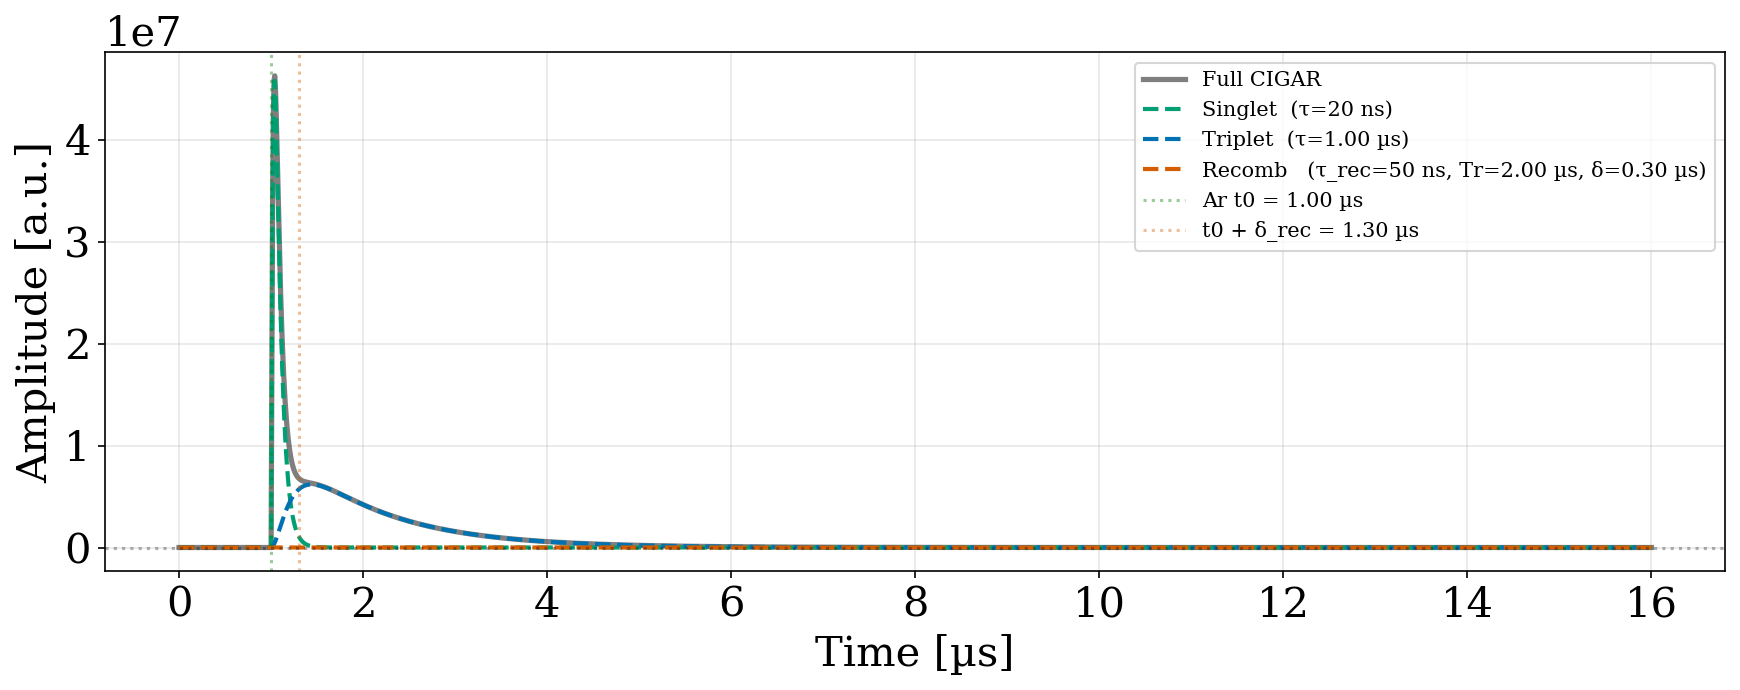

In [14]:
# =========================================================================== #
#  EXPLORER CELL — edit dicts and re-run                                       #
# =========================================================================== #
time = np.linspace(0, 16e-6, 2000)
t0_ar = time[125]   # Ar scintillation onset [s]

sipm_rise  = 1e-9    # fixed SiPM rise  [s]
sipm_decay = 64e-9   # fixed SiPM decay [s]

singlet_p = dict(
    A    = 5.0,
    rise = 2e-9,
    tau  = 20e-9,
)

triplet_p = dict(
    A    = 9.0,
    rise = 200e-9,
    tau  = 1e-6,
)

rec_p = dict(
    A         = 2.0,
    tau_rec   = 50e-9,
    Tr        = 2e-6,
    delta_rec = 0.3e-6,
)

# ---- compute ------------------------------------------------------------- #
u    = time - t0_ar
mask = u > 0

h_singlet       = np.zeros_like(time)
h_singlet[mask] = _conv_two_rise_decay(u[mask],
                                        singlet_p['rise'], singlet_p['tau'],
                                        sipm_rise, sipm_decay)
area = np.trapz(h_singlet, x=time)
if area > 0: h_singlet *= singlet_p['A'] / area

h_triplet       = np.zeros_like(time)
h_triplet[mask] = _conv_two_rise_decay(u[mask],
                                        triplet_p['rise'], triplet_p['tau'],
                                        sipm_rise, sipm_decay)
area = np.trapz(h_triplet, x=time)
if area > 0: h_triplet *= triplet_p['A'] / area

h_rec = rec_p['A'] * recombination_model(time,
                                          t0_ar + rec_p['delta_rec'],
                                          rec_p['tau_rec'], rec_p['Tr'])

full = h_singlet + h_triplet + h_rec

# ---- plot ---------------------------------------------------------------- #
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

ax.plot(time * 1e6, full,      color='black',   lw=2.5, alpha=0.5,
        label='Full CIGAR')
ax.plot(time * 1e6, h_singlet, color='#009E73', lw=2,   ls='--',
        label=f'Singlet  (τ={singlet_p["tau"]*1e9:.0f} ns)')
ax.plot(time * 1e6, h_triplet, color='#0072B2', lw=2,   ls='--',
        label=f'Triplet  (τ={triplet_p["tau"]*1e6:.2f} µs)')
ax.plot(time * 1e6, h_rec,     color='#D55E00', lw=2,   ls='--',
        label=f'Recomb   (τ_rec={rec_p["tau_rec"]*1e9:.0f} ns, '
              f'Tr={rec_p["Tr"]*1e6:.2f} µs, '
              f'δ={rec_p["delta_rec"]*1e6:.2f} µs)')

ax.axvline(t0_ar * 1e6, color='green', ls=':', alpha=0.4,
           label=f'Ar t0 = {t0_ar*1e6:.2f} µs')
ax.axvline((t0_ar + rec_p['delta_rec']) * 1e6, color='#D55E00', ls=':', alpha=0.4,
           label=f't0 + δ_rec = {(t0_ar+rec_p["delta_rec"])*1e6:.2f} µs')
ax.axhline(0, color='k', ls=':', alpha=0.3)

ax.set_xlabel('Time [µs]')
ax.set_ylabel('Amplitude [a.u.]')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# after fit_cigar_waveforms returns cigar_params:
check_timescale_validity(singlet_p['tau'], triplet_p['tau'], rec_p['Tr'])


SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 3.200  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.064  →  ✗ full convolution needed
  t_sipm / tau_recombination Tr   = 0.032  →  ✓ delta approx valid


##  Signal time constants

In [16]:
run    = {
           8.5:f'Run{171}' 
         #   7.5:f'Run{173}'
        #    6.5:f'Run{175}'
        #    5.5:f'Run{177}'
         #   4.5:f'Run{179}'
        #    3.5:f'Run{181}'
        #    2.5:f'Run{183}'
         #   1.5:f'Run{185}'
           }

  ⚠ [CH1] rise_singlet hit lower bound: value=1.1897e-11  lower=1.0000e-11
  ⚠ [CH1] tau_rec      hit lower bound: value=8.8550e-09  lower=1.0000e-09
  ⚠ [CH1] pcov ill-conditioned (cond=6.8e+18) — errors unreliable
  ⚠ [CH2] rise_singlet hit lower bound: value=1.1087e-11  lower=1.0000e-11
  ⚠ [CH2] tau_rec      hit lower bound: value=1.0749e-08  lower=1.0000e-09
  ⚠ [CH2] pcov ill-conditioned (cond=2.8e+19) — errors unreliable
  ⚠ [CH3] rise_singlet hit lower bound: value=1.3963e-11  lower=1.0000e-11
  ⚠ [CH3] tau_rec      hit upper bound: value=1.0000e-06  upper=1.0000e-06
  ⚠ [CH3] Tr           hit upper bound: value=5.0000e-05  upper=5.0000e-05
  ⚠ [CH3] pcov ill-conditioned (cond=4.6e+18) — errors unreliable
  ⚠ [CH4] rise_singlet hit lower bound: value=1.3999e-11  lower=1.0000e-11
  ⚠ [CH4] tau_rec      hit upper bound: value=1.0000e-06  upper=1.0000e-06
  ⚠ [CH4] Tr           hit upper bound: value=5.0000e-05  upper=5.0000e-05
  ⚠ [CH4] pcov ill-conditioned (cond=2.8e+19) — erro

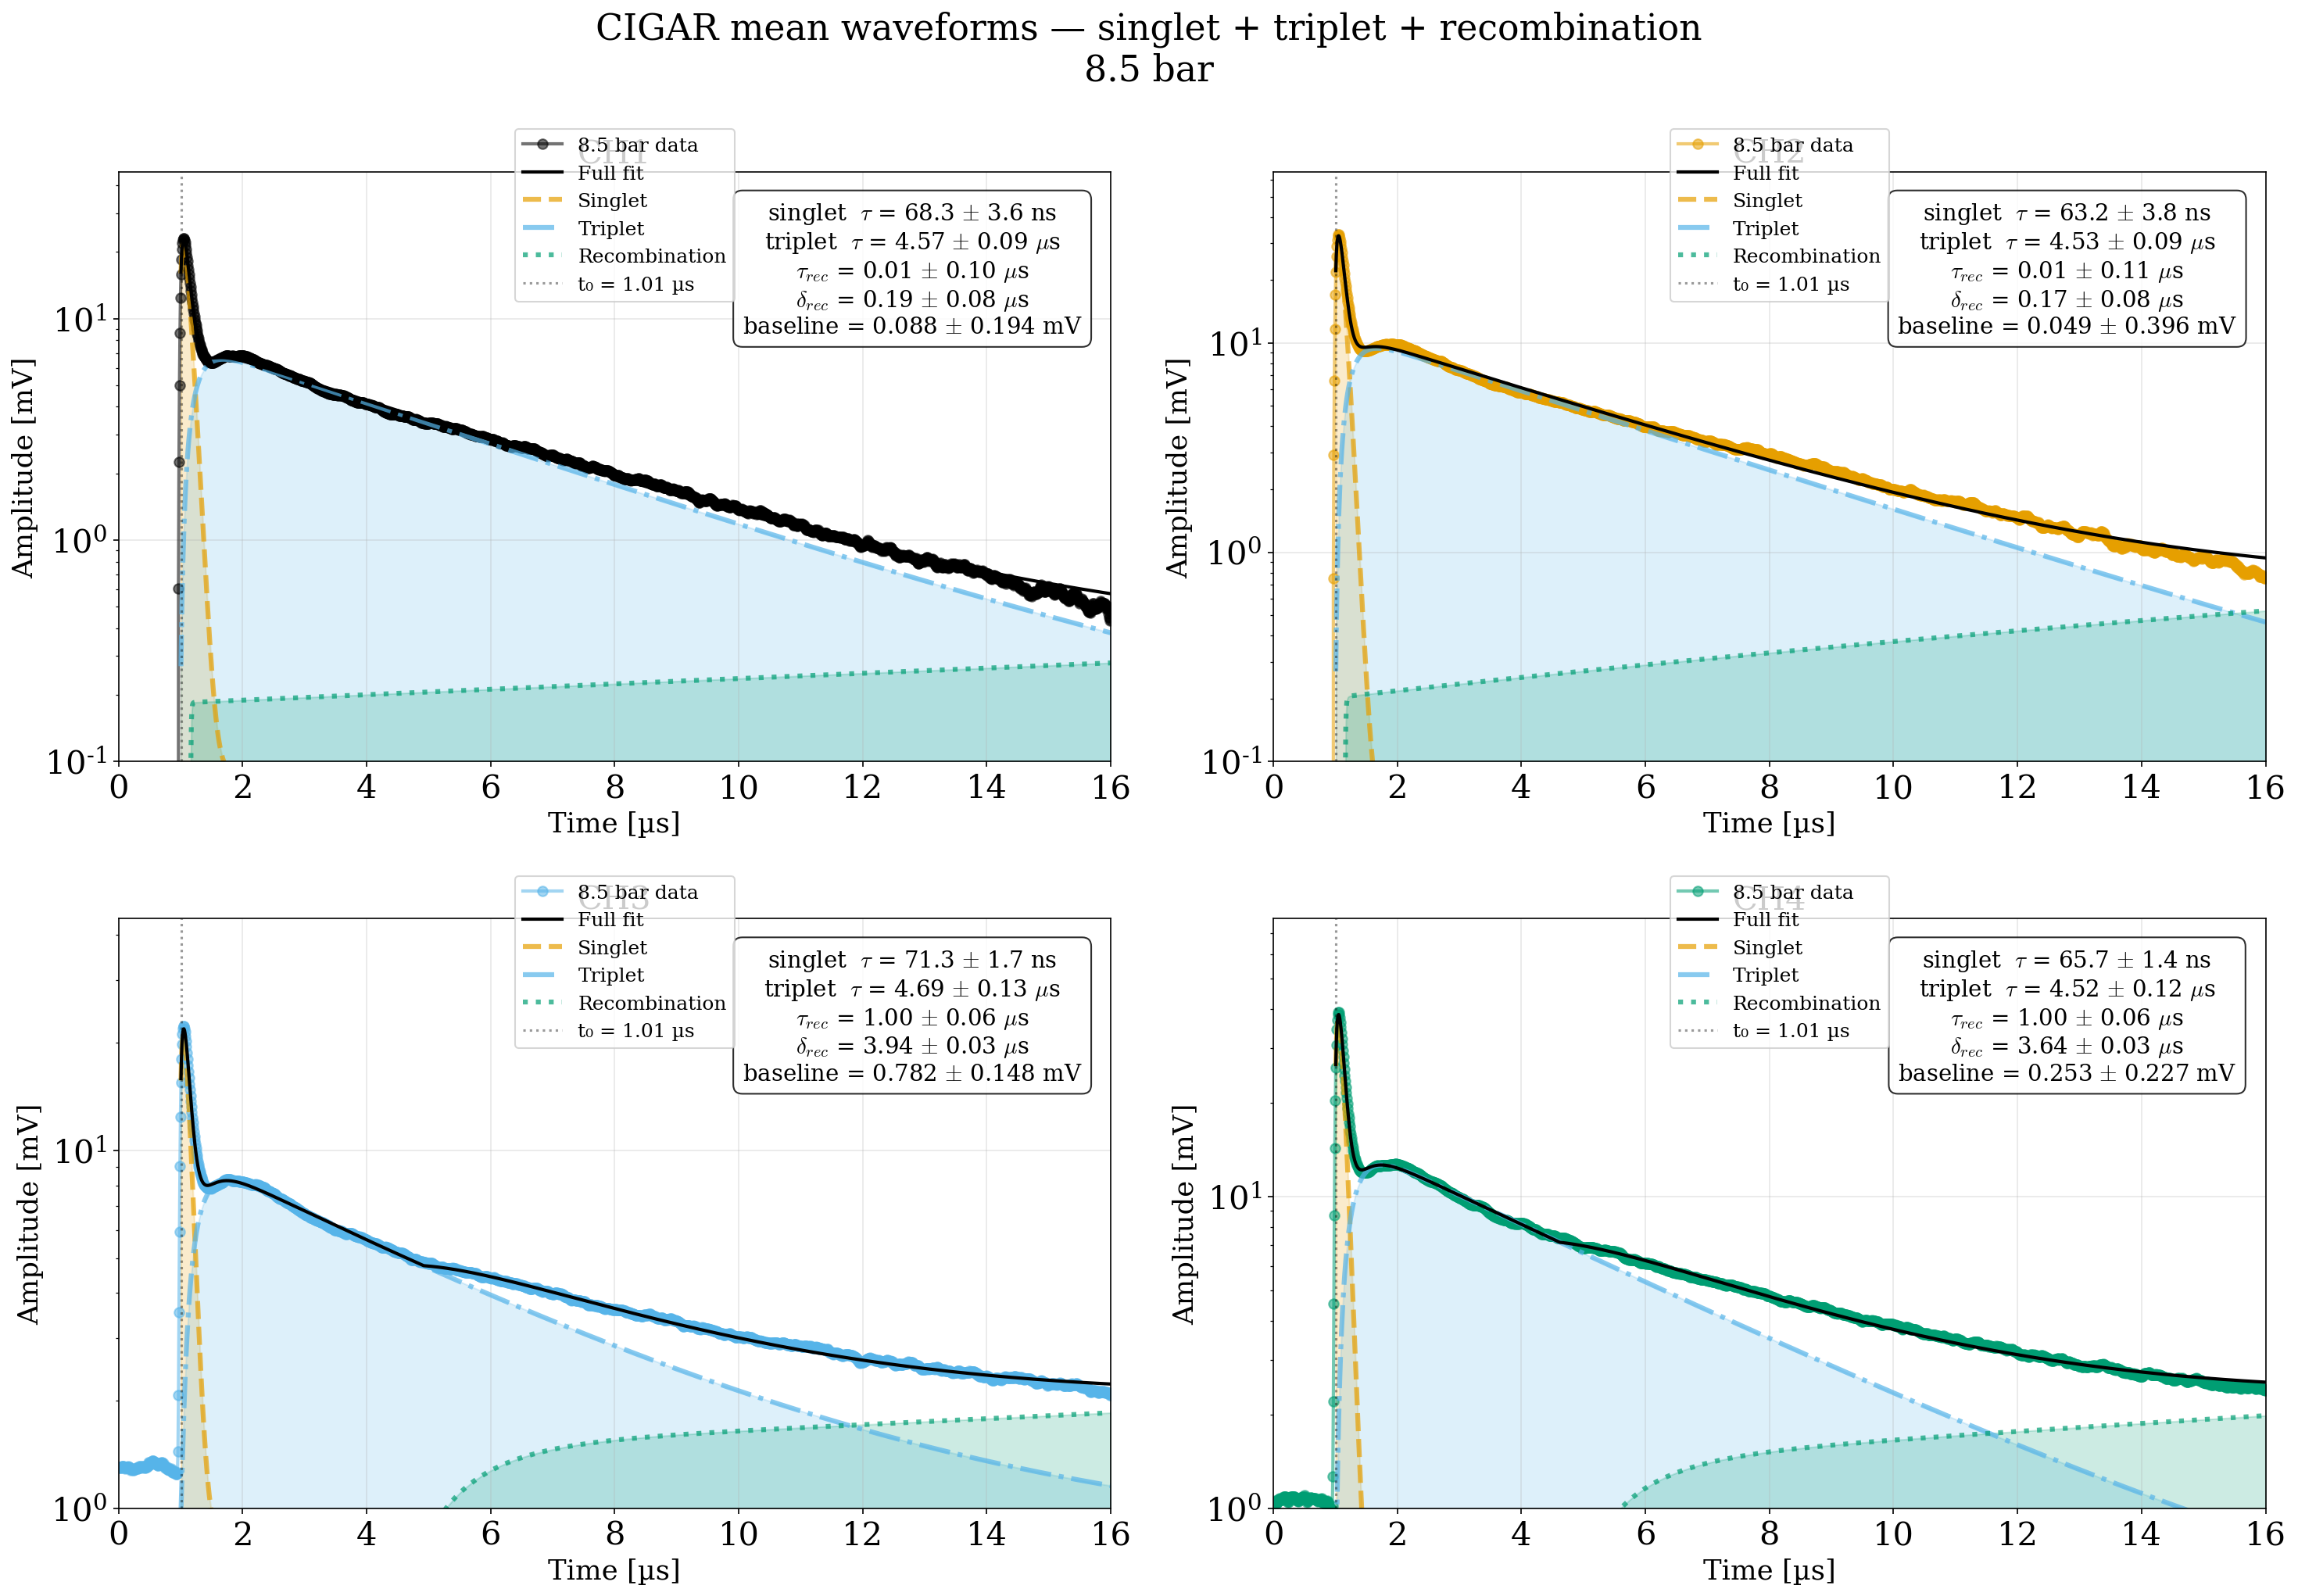

In [17]:
fig_cig, axs, cigar_params = fit_cigar_waveforms(run, base,
                                                  pretrigger_sample=125,
                                                  channels_to_show=None, invert=True,
                                                  p0_cigar=None, bounds_cigar=None,
                                                  colors=None, font_size=20,
                                                  logscale=True)

for ax in axs.flatten():
    ax.set_ylim(1, 30)

plt.show()

In [18]:
runs    = {
           8.5:f'Run{171}' 
           ,7.5:f'Run{173}'
           ,6.5:f'Run{175}'
           ,5.5:f'Run{177}'
           ,4.5:f'Run{179}'
           ,3.5:f'Run{181}'
           ,2.5:f'Run{183}'
           ,1.5:f'Run{185}'
           }

  ⚠ [CH1] rise_singlet hit lower bound: value=1.1897e-11  lower=1.0000e-11
  ⚠ [CH1] tau_rec      hit lower bound: value=8.8550e-09  lower=1.0000e-09
  ⚠ [CH1] pcov ill-conditioned (cond=6.8e+18) — errors unreliable
  ⚠ [CH2] rise_singlet hit lower bound: value=1.1087e-11  lower=1.0000e-11
  ⚠ [CH2] tau_rec      hit lower bound: value=1.0749e-08  lower=1.0000e-09
  ⚠ [CH2] pcov ill-conditioned (cond=2.8e+19) — errors unreliable
  ⚠ [CH3] rise_singlet hit lower bound: value=1.3963e-11  lower=1.0000e-11
  ⚠ [CH3] tau_rec      hit upper bound: value=1.0000e-06  upper=1.0000e-06
  ⚠ [CH3] Tr           hit upper bound: value=5.0000e-05  upper=5.0000e-05
  ⚠ [CH3] pcov ill-conditioned (cond=4.6e+18) — errors unreliable
  ⚠ [CH4] rise_singlet hit lower bound: value=1.3999e-11  lower=1.0000e-11
  ⚠ [CH4] tau_rec      hit upper bound: value=1.0000e-06  upper=1.0000e-06
  ⚠ [CH4] Tr           hit upper bound: value=5.0000e-05  upper=5.0000e-05
  ⚠ [CH4] pcov ill-conditioned (cond=2.8e+19) — erro

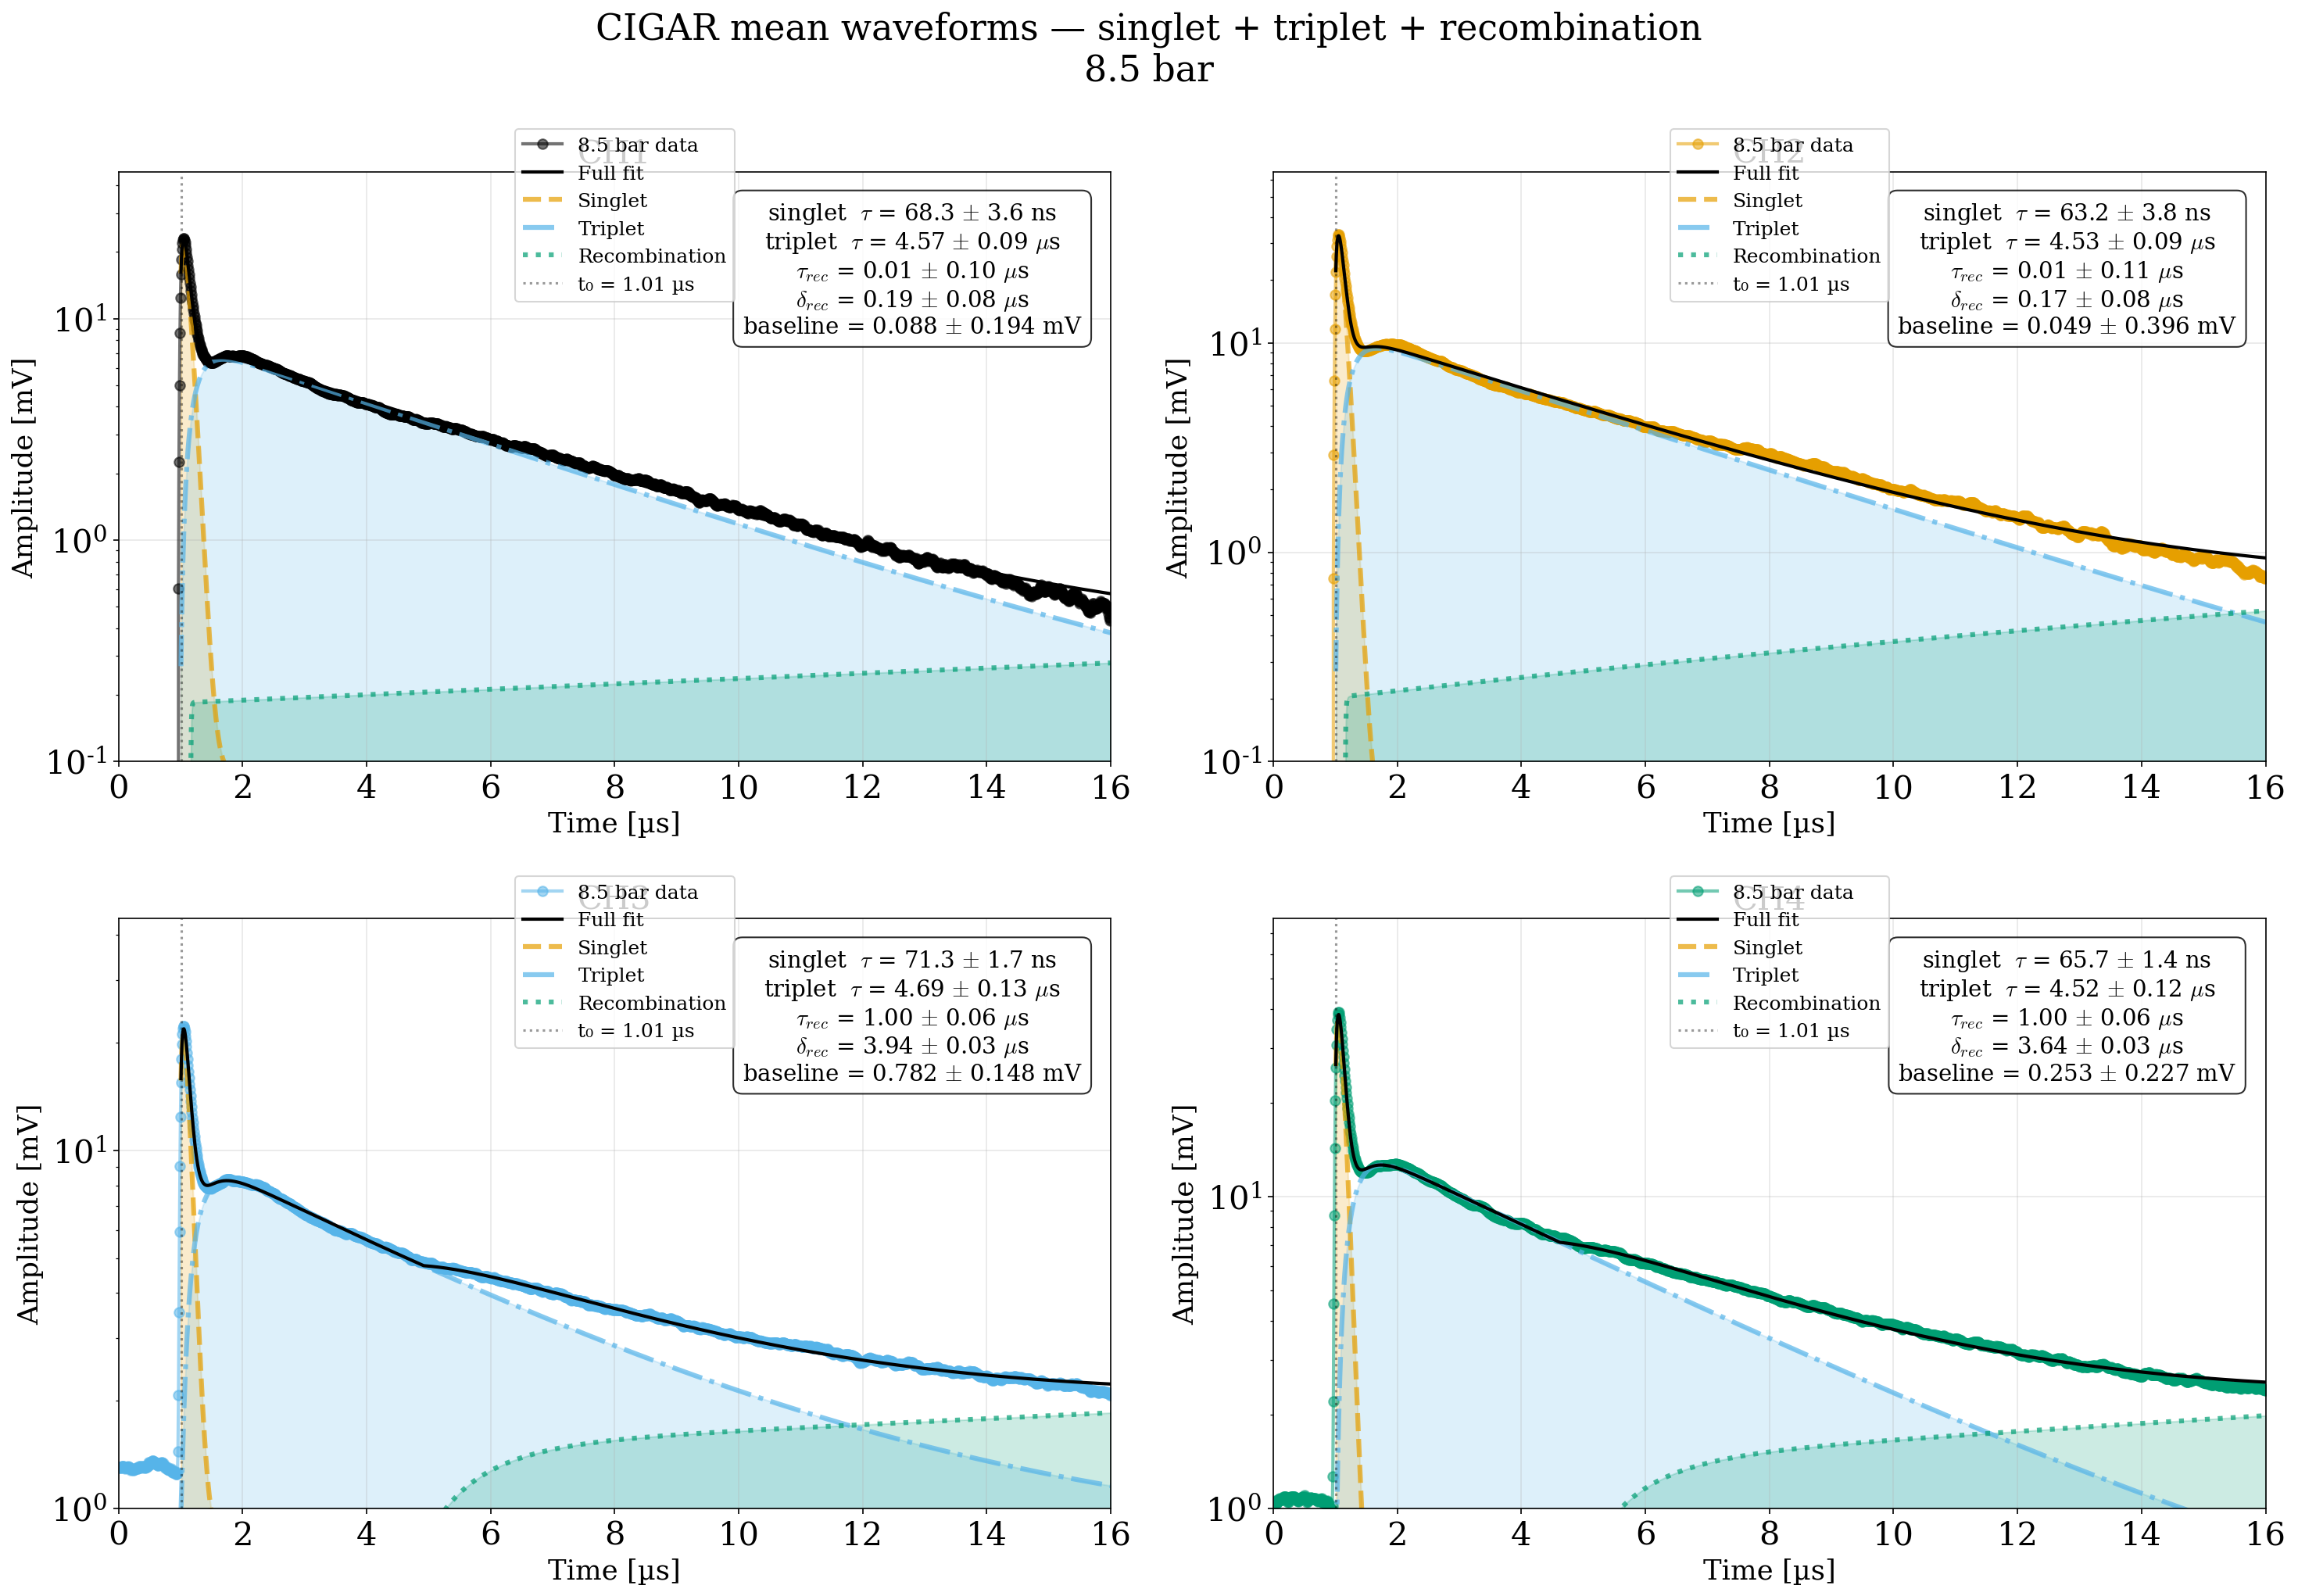


=== CH1  @  8.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.937  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.014  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.002  →  ✓ delta approx valid

=== CH2  @  8.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 1.012  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.014  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.003  →  ✓ delta approx valid

=== CH3  @  8.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.898  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.014  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.001  →  ✓ delta approx valid

=== CH4  @  8.5 bar ===

SiPM decay 

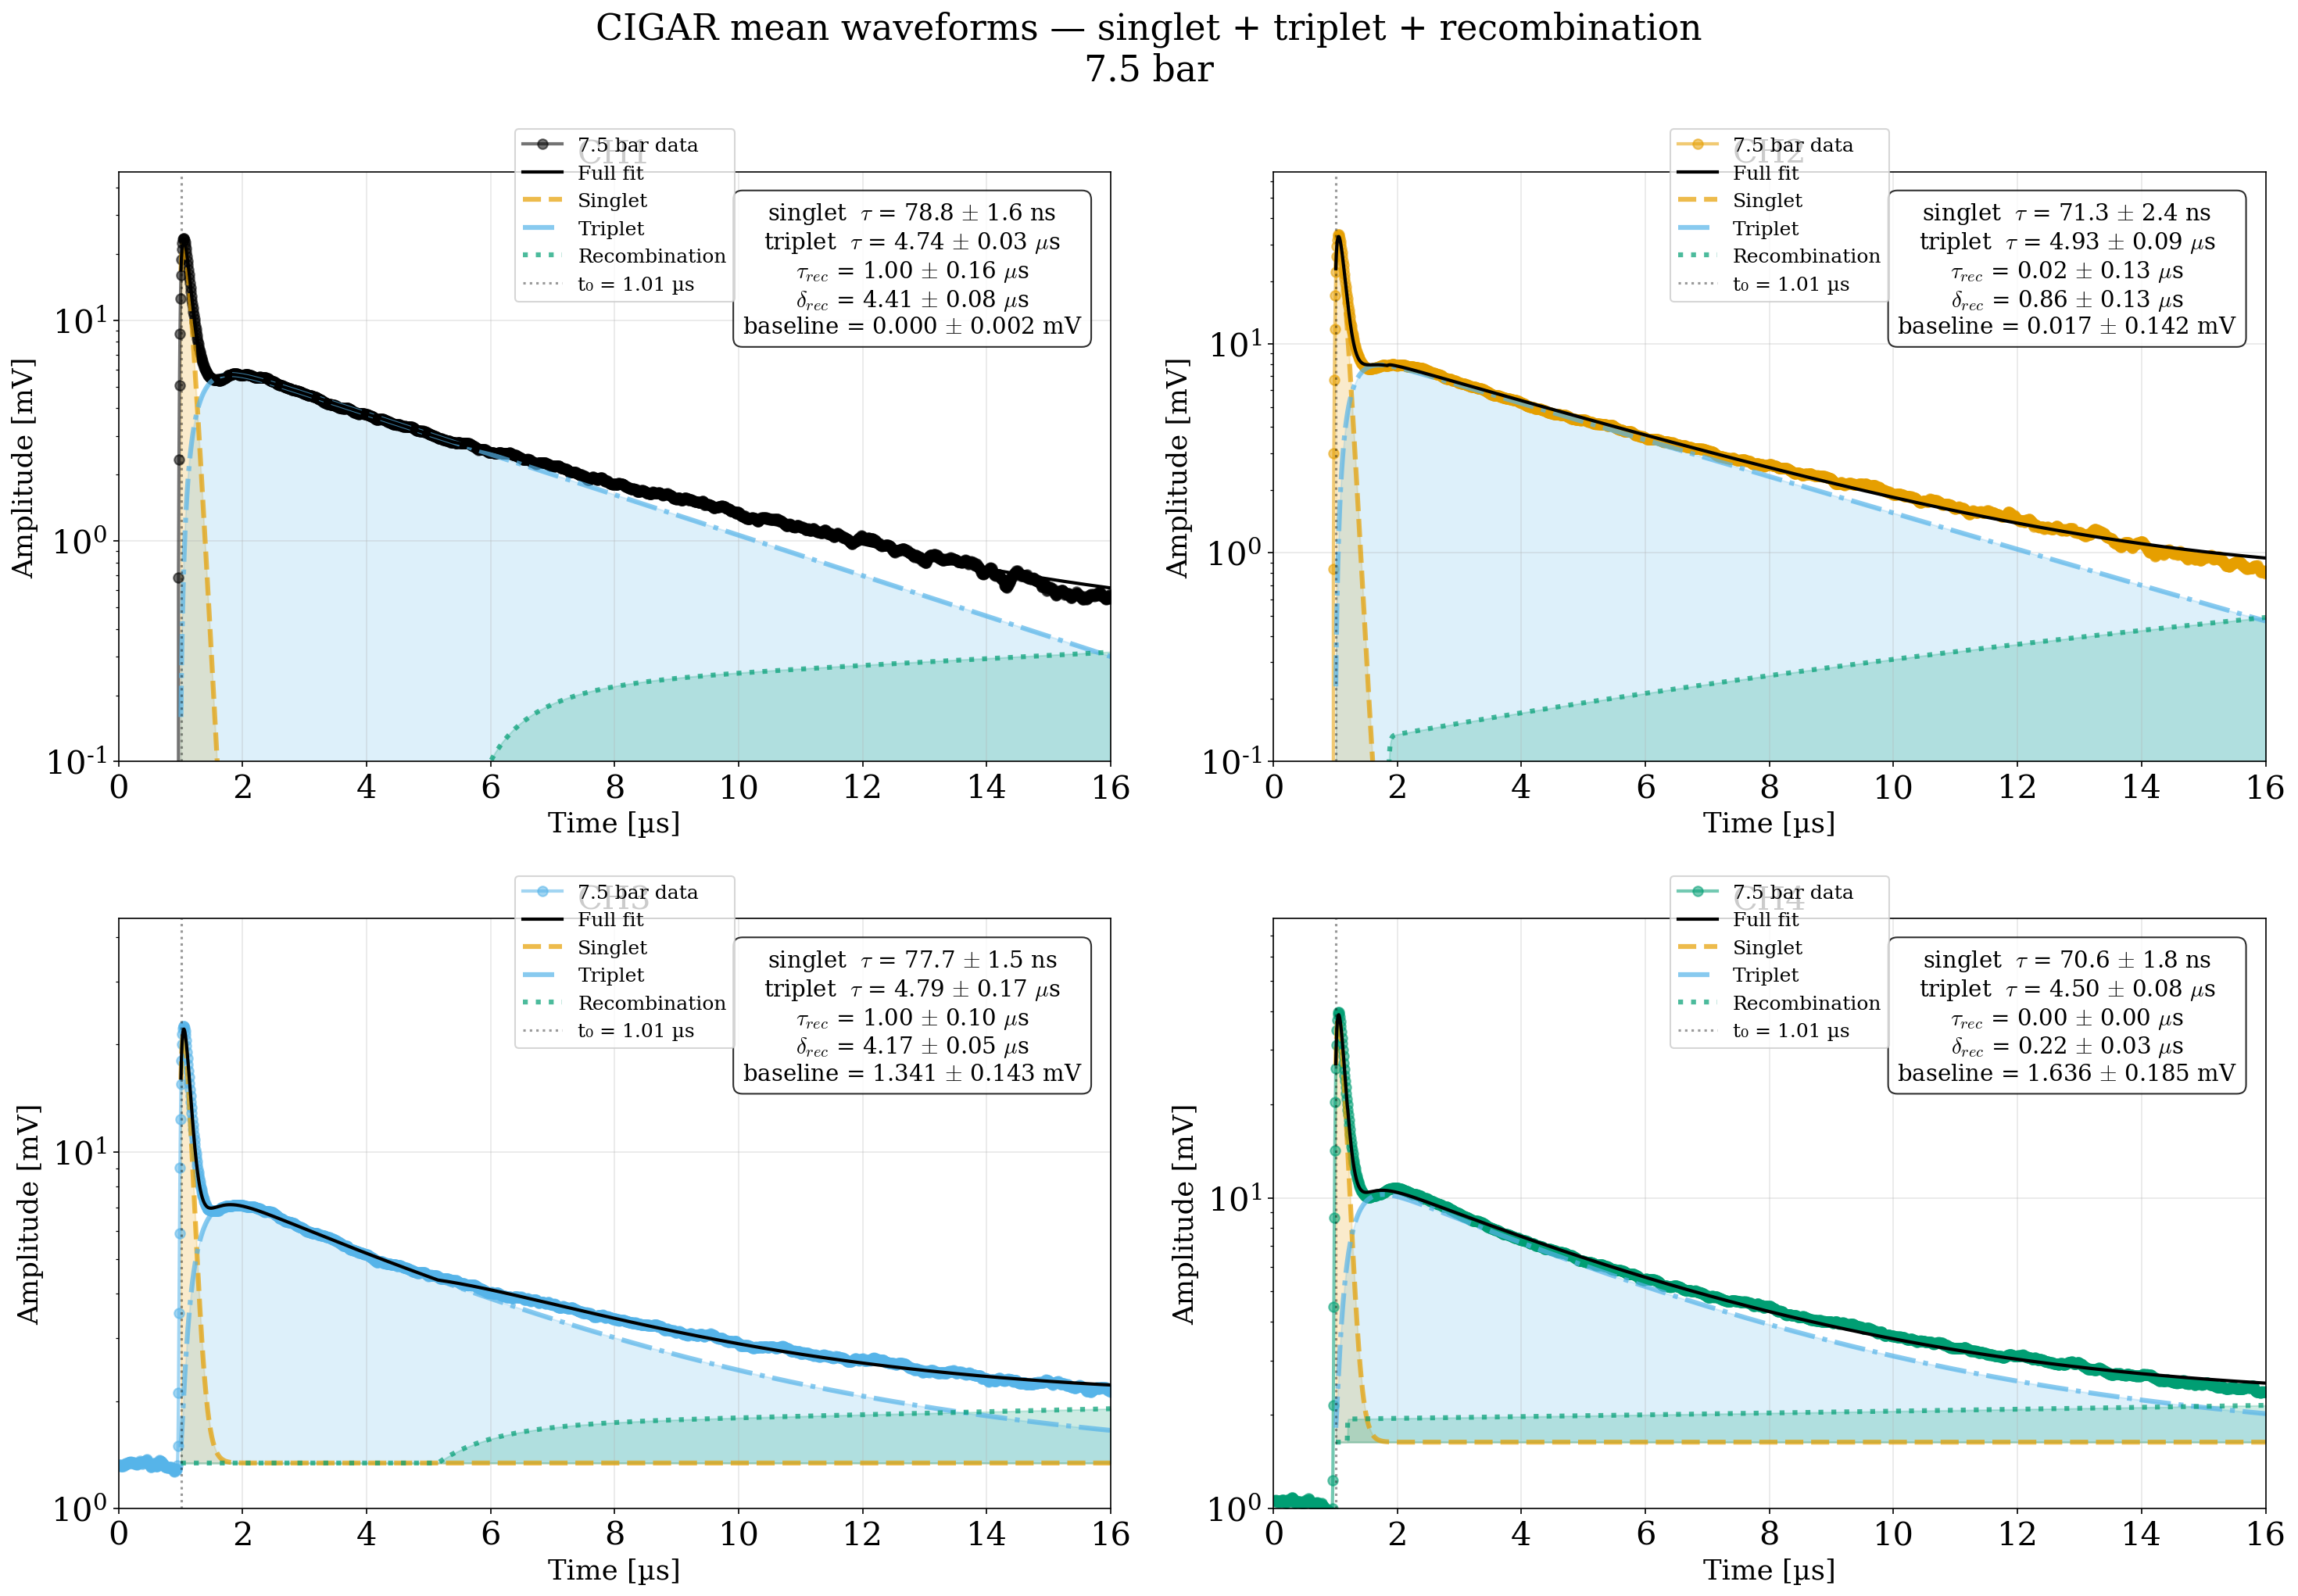


=== CH1  @  7.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.812  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.014  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.001  →  ✓ delta approx valid

=== CH2  @  7.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.898  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.013  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.005  →  ✓ delta approx valid

=== CH3  @  7.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.824  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.013  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.001  →  ✓ delta approx valid

=== CH4  @  7.5 bar ===

SiPM decay 

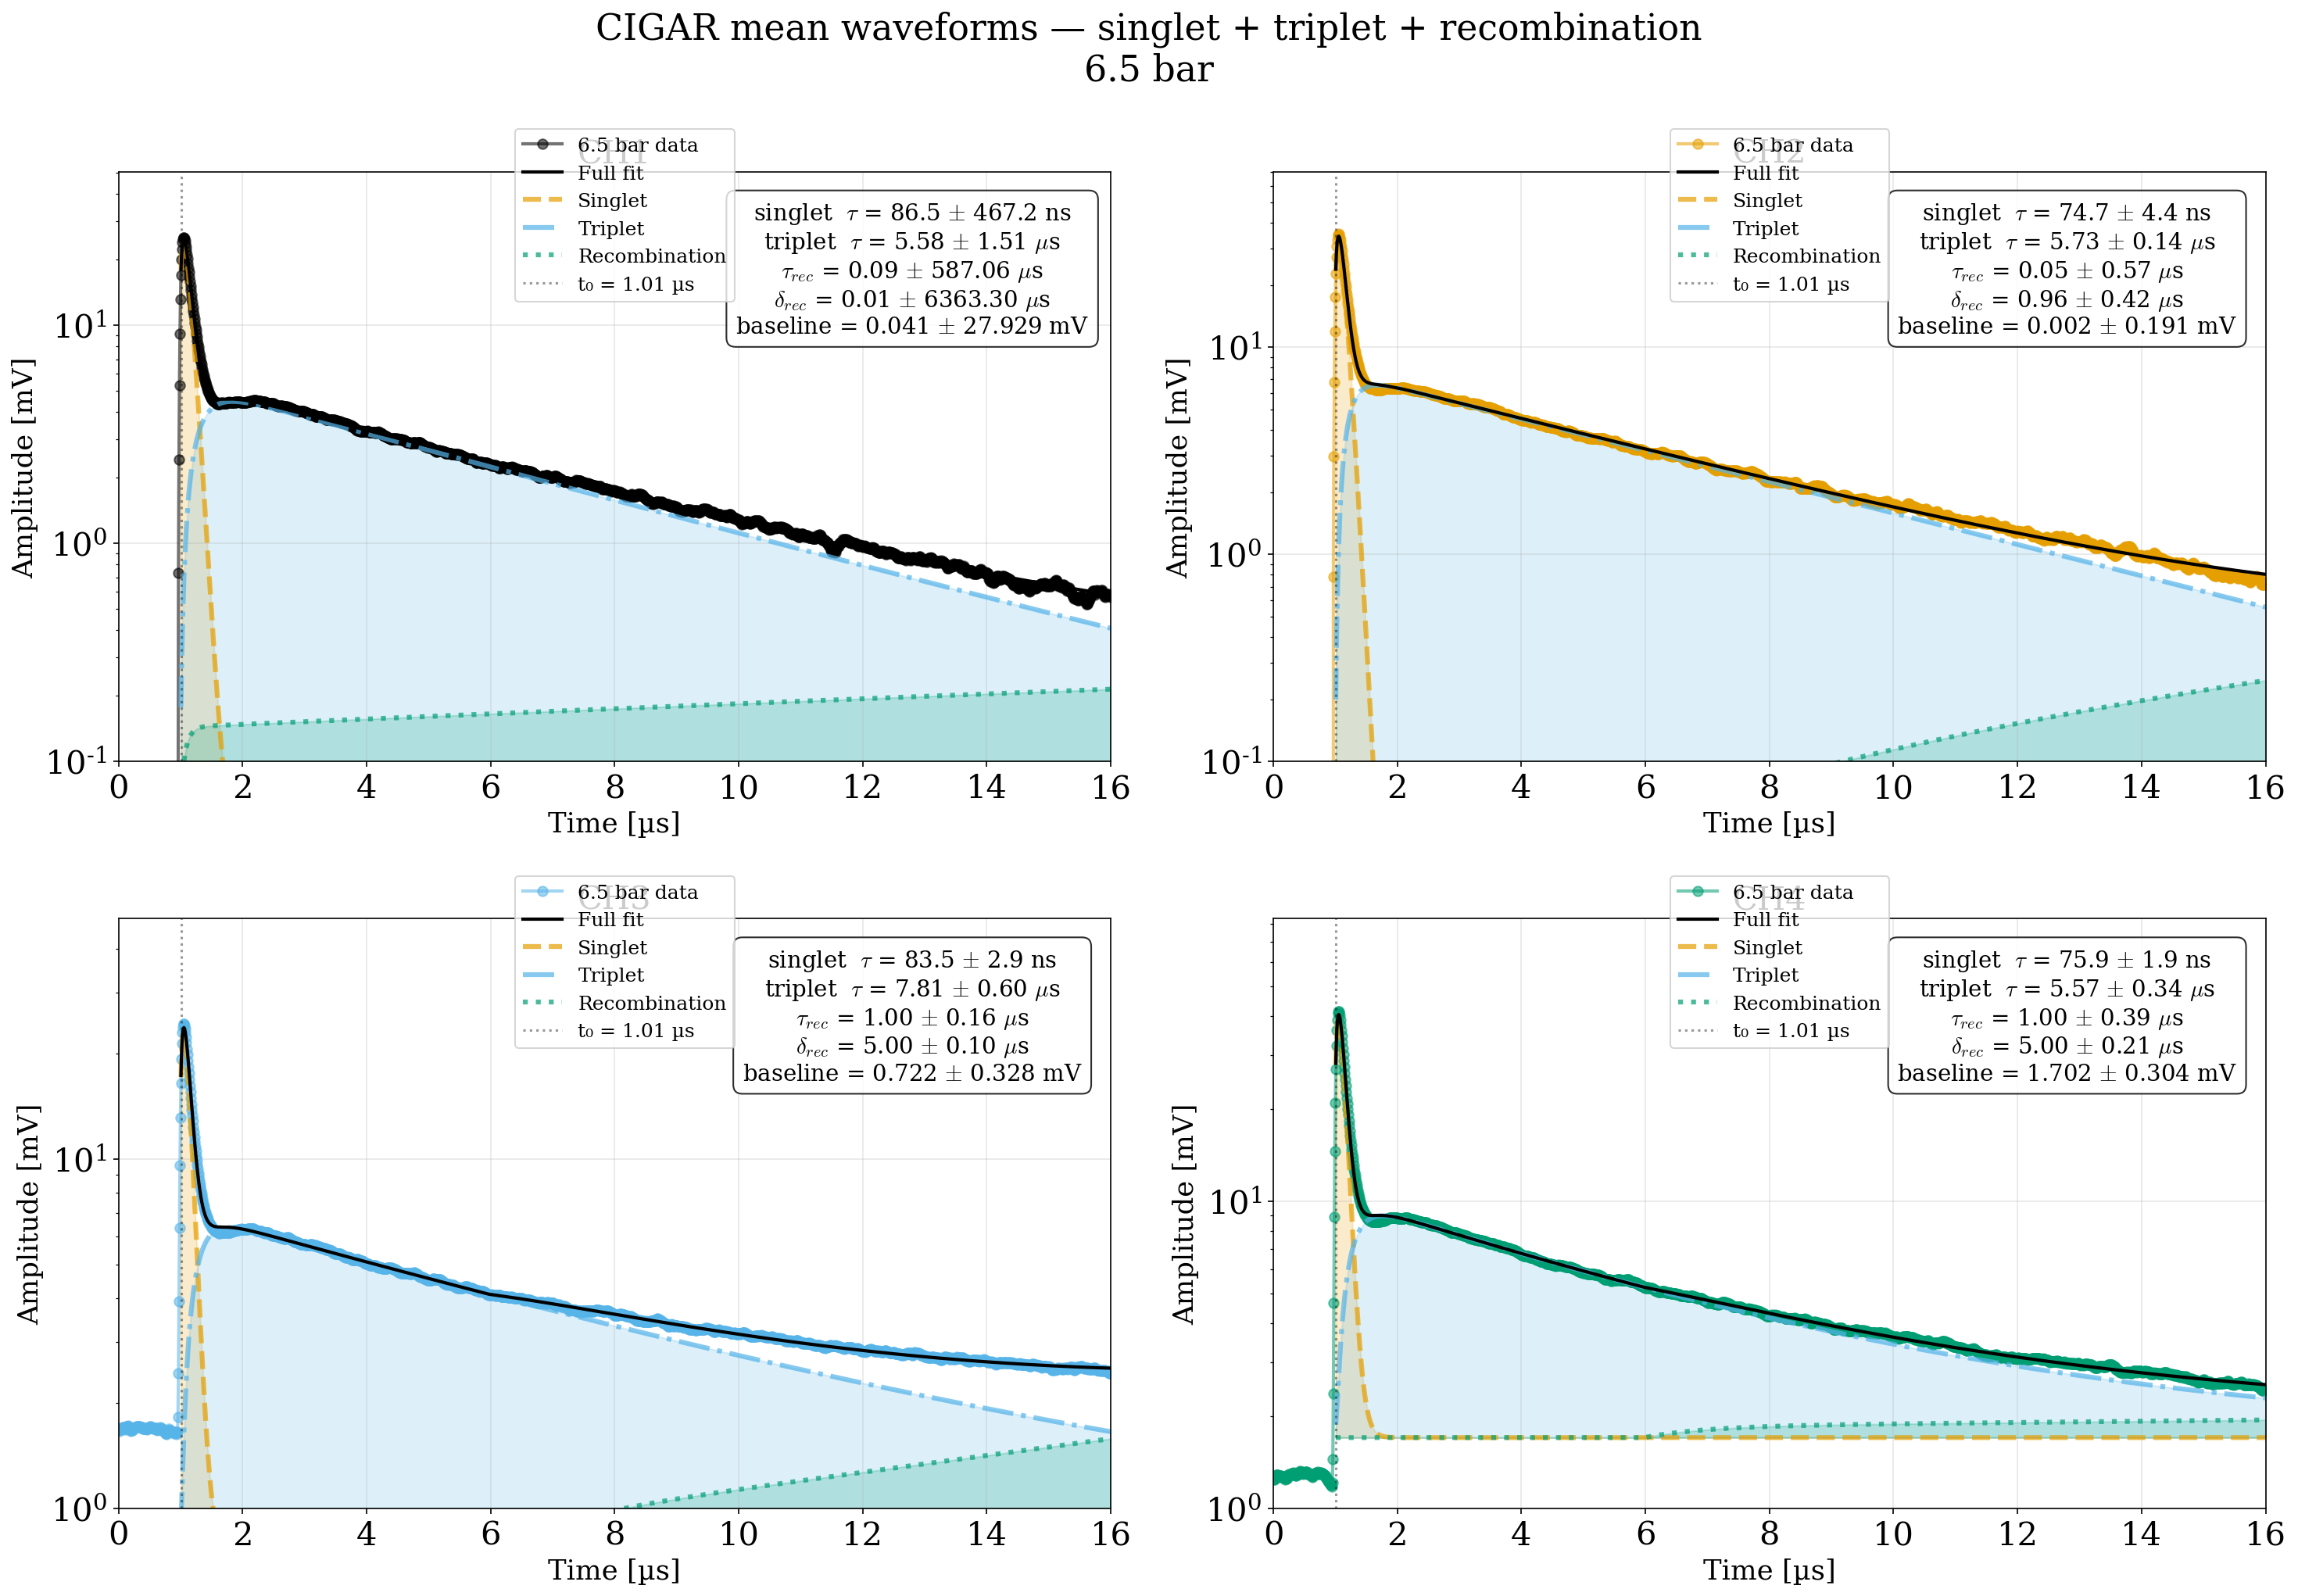


=== CH1  @  6.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.740  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.011  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.001  →  ✓ delta approx valid

=== CH2  @  6.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.856  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.011  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.014  →  ✓ delta approx valid

=== CH3  @  6.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.766  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.008  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.007  →  ✓ delta approx valid

=== CH4  @  6.5 bar ===

SiPM decay 

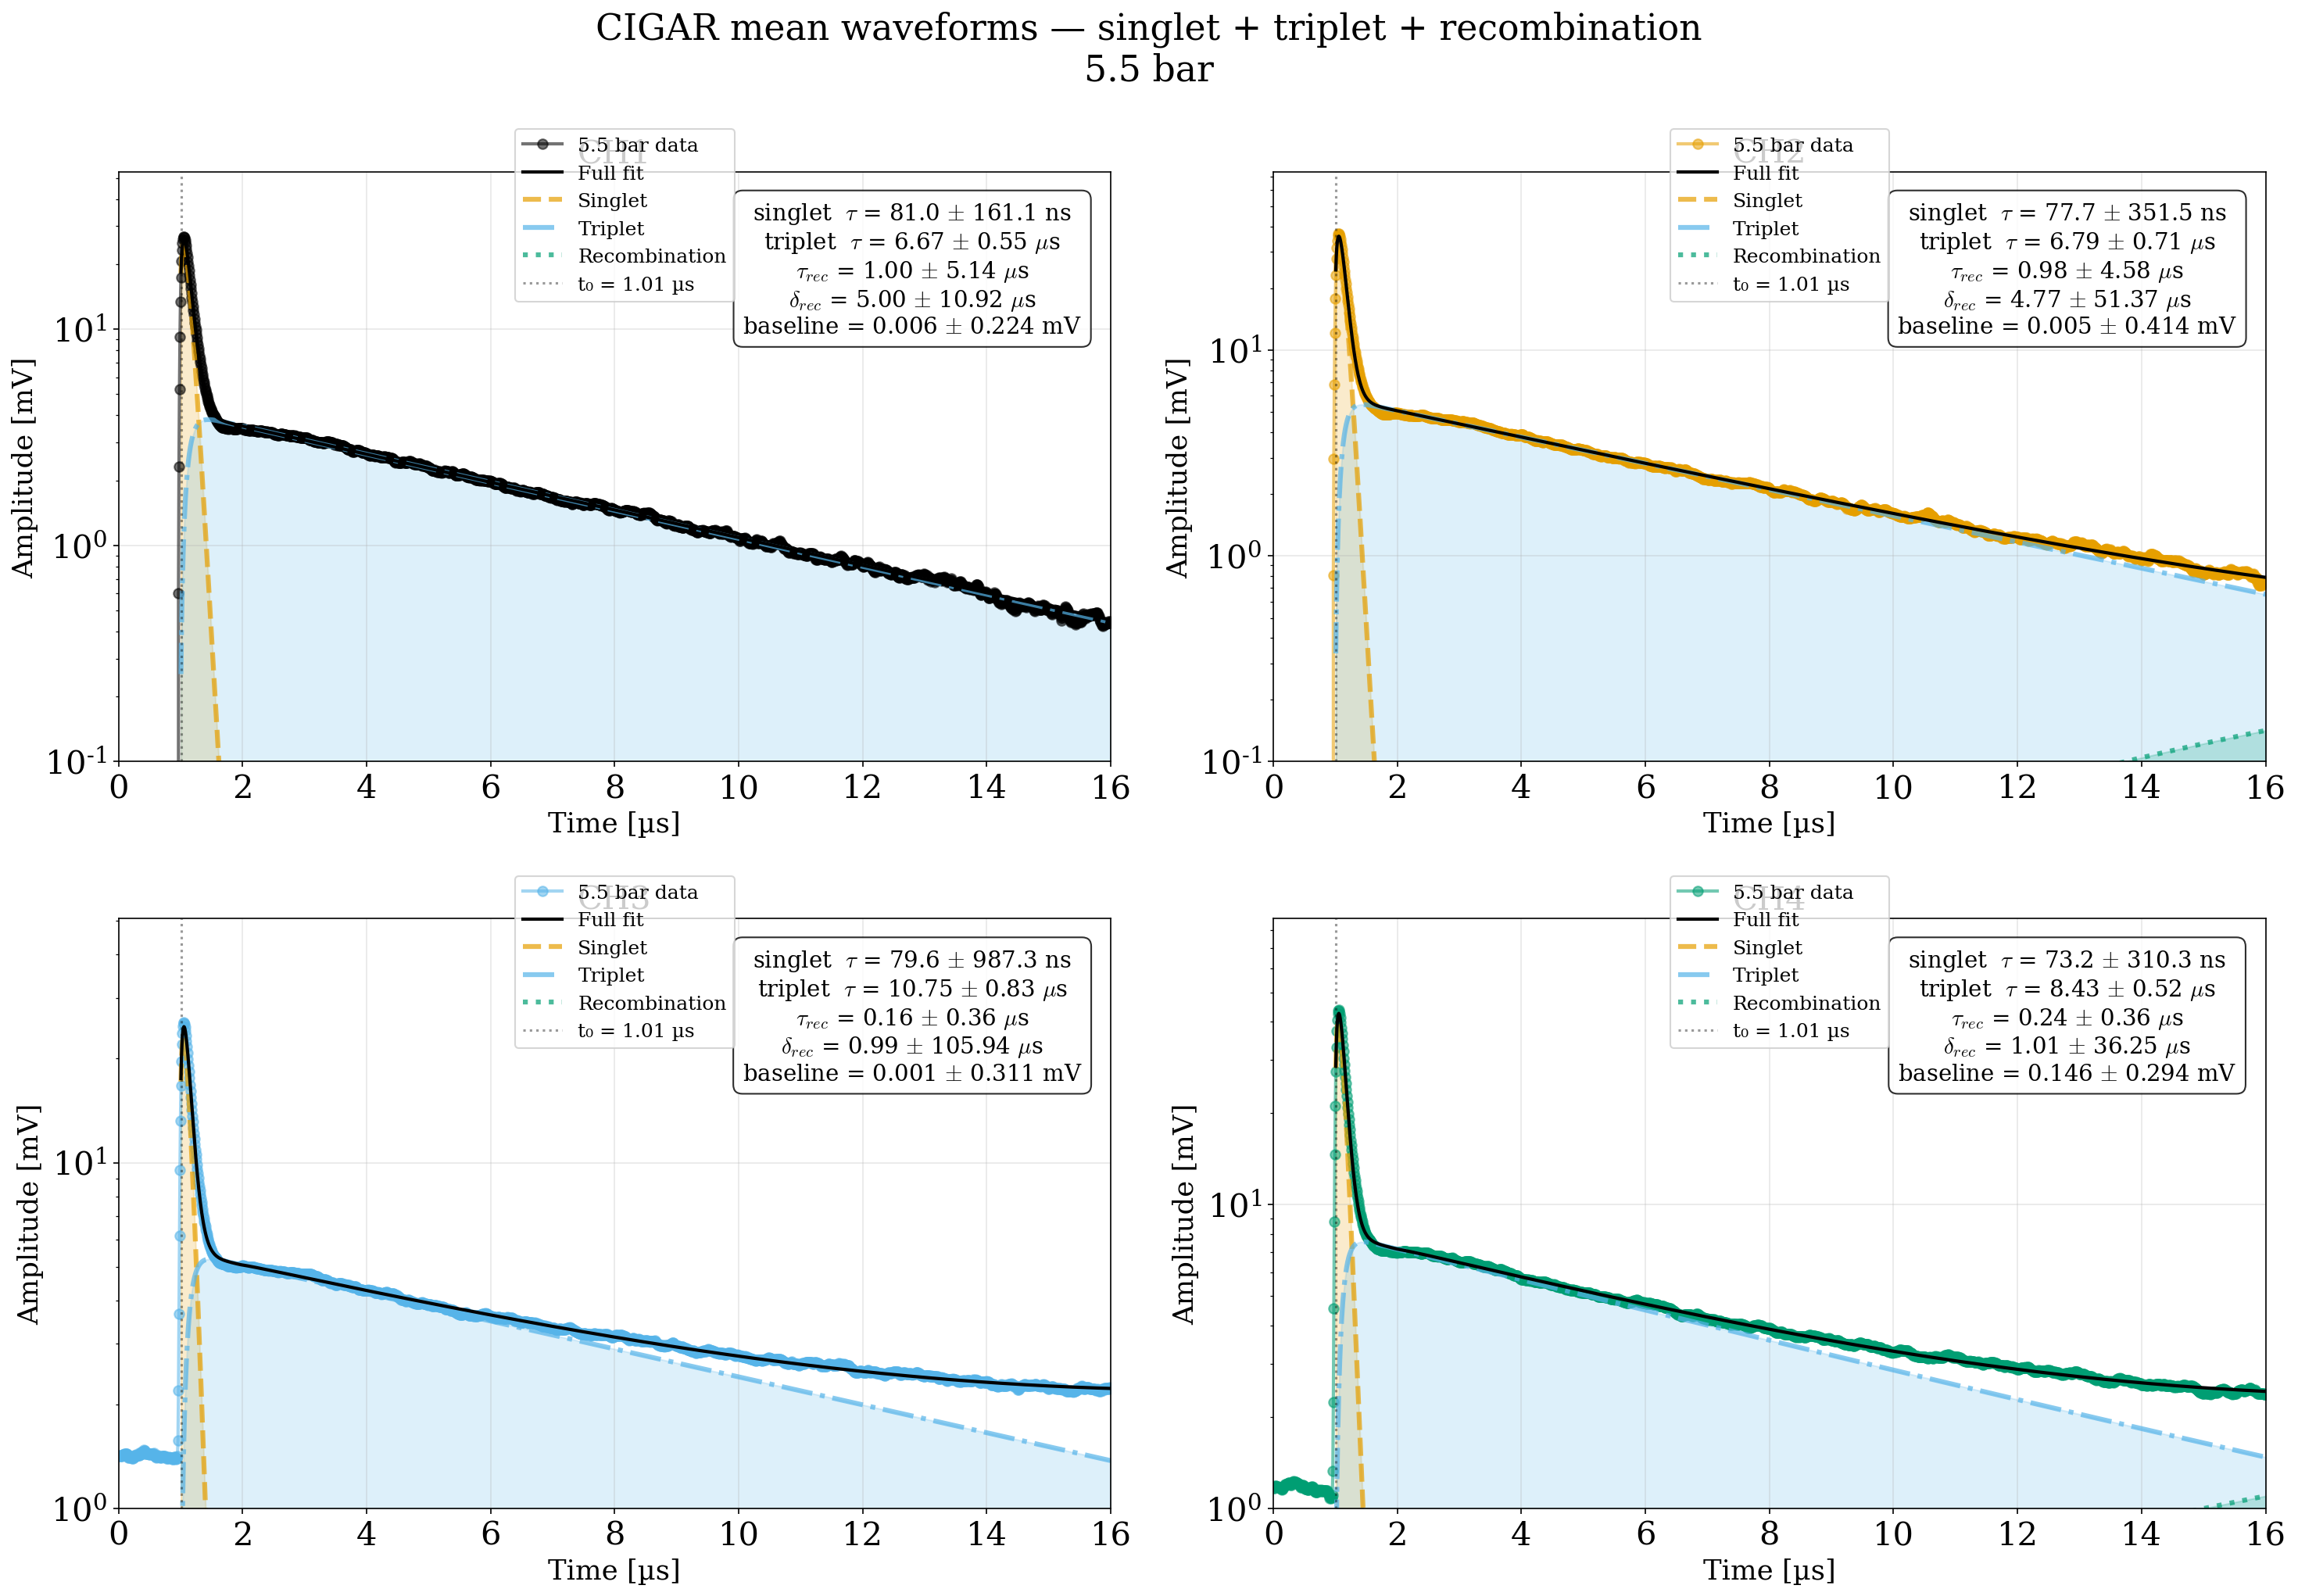


=== CH1  @  5.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.790  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.010  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.001  →  ✓ delta approx valid

=== CH2  @  5.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.824  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.009  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.019  →  ✓ delta approx valid

=== CH3  @  5.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.805  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.006  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.021  →  ✓ delta approx valid

=== CH4  @  5.5 bar ===

SiPM decay 

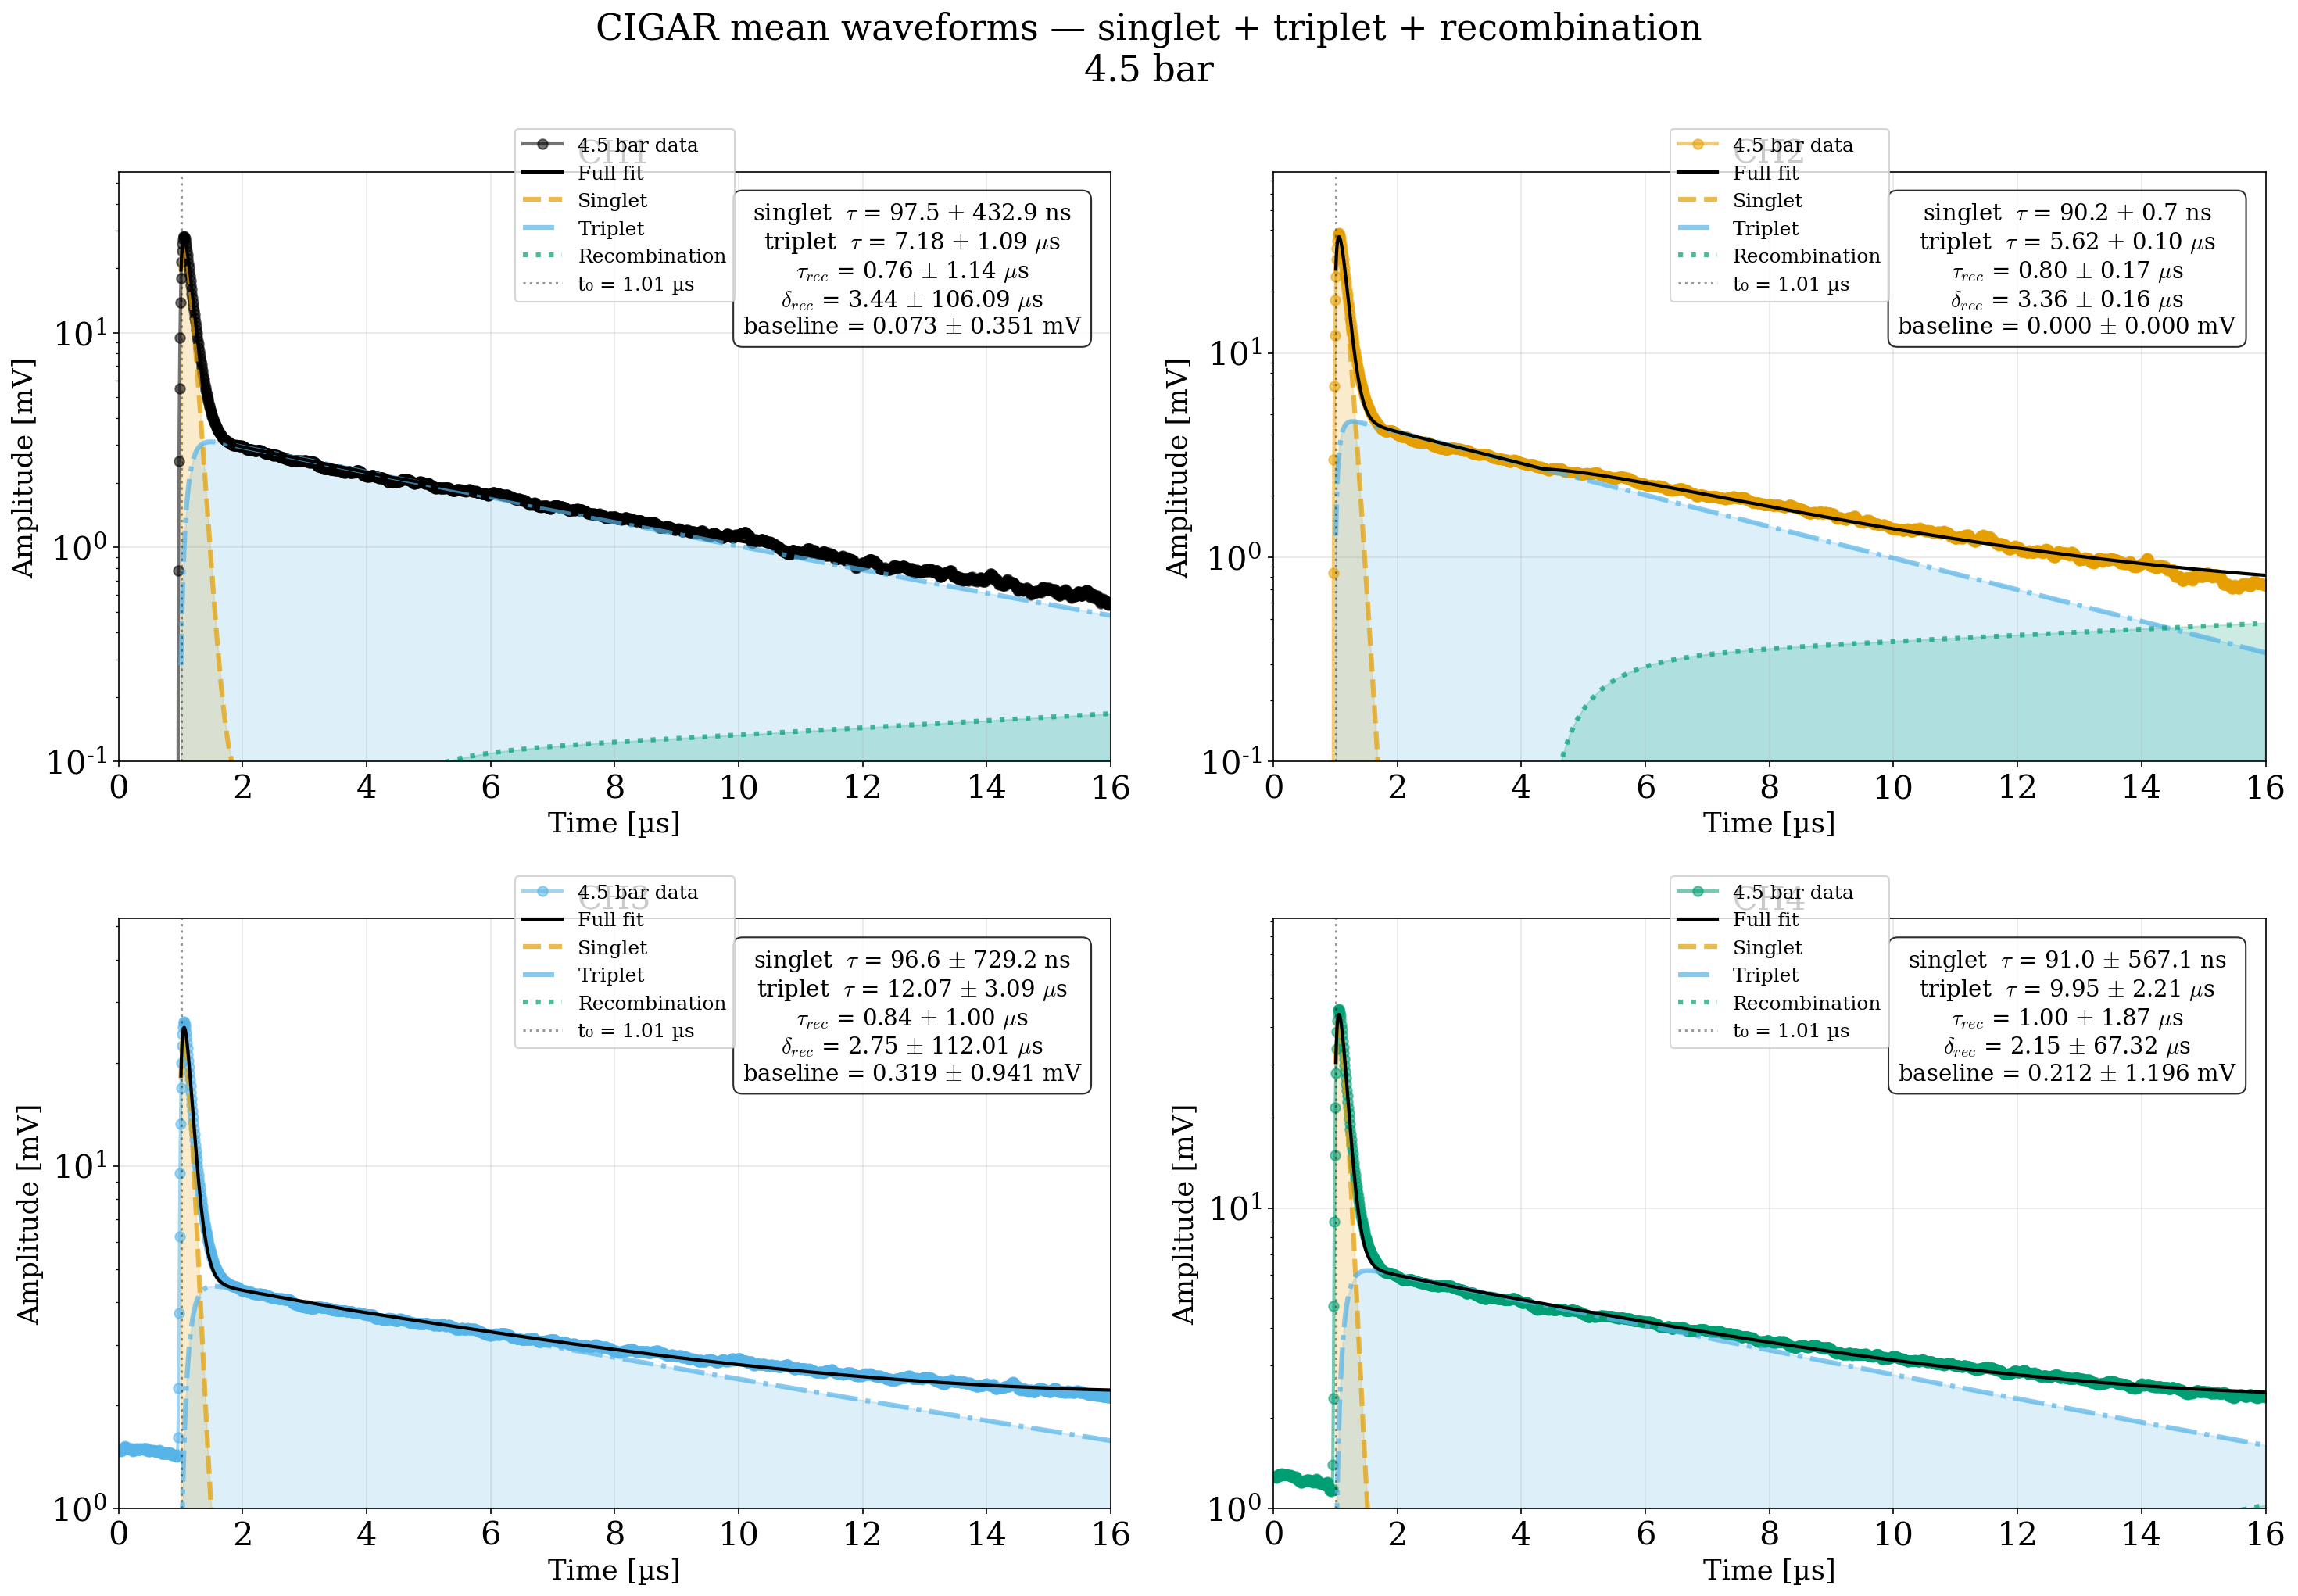


=== CH1  @  4.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.657  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.009  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.003  →  ✓ delta approx valid

=== CH2  @  4.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.710  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.011  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.001  →  ✓ delta approx valid

=== CH3  @  4.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.662  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.005  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.019  →  ✓ delta approx valid

=== CH4  @  4.5 bar ===

SiPM decay 

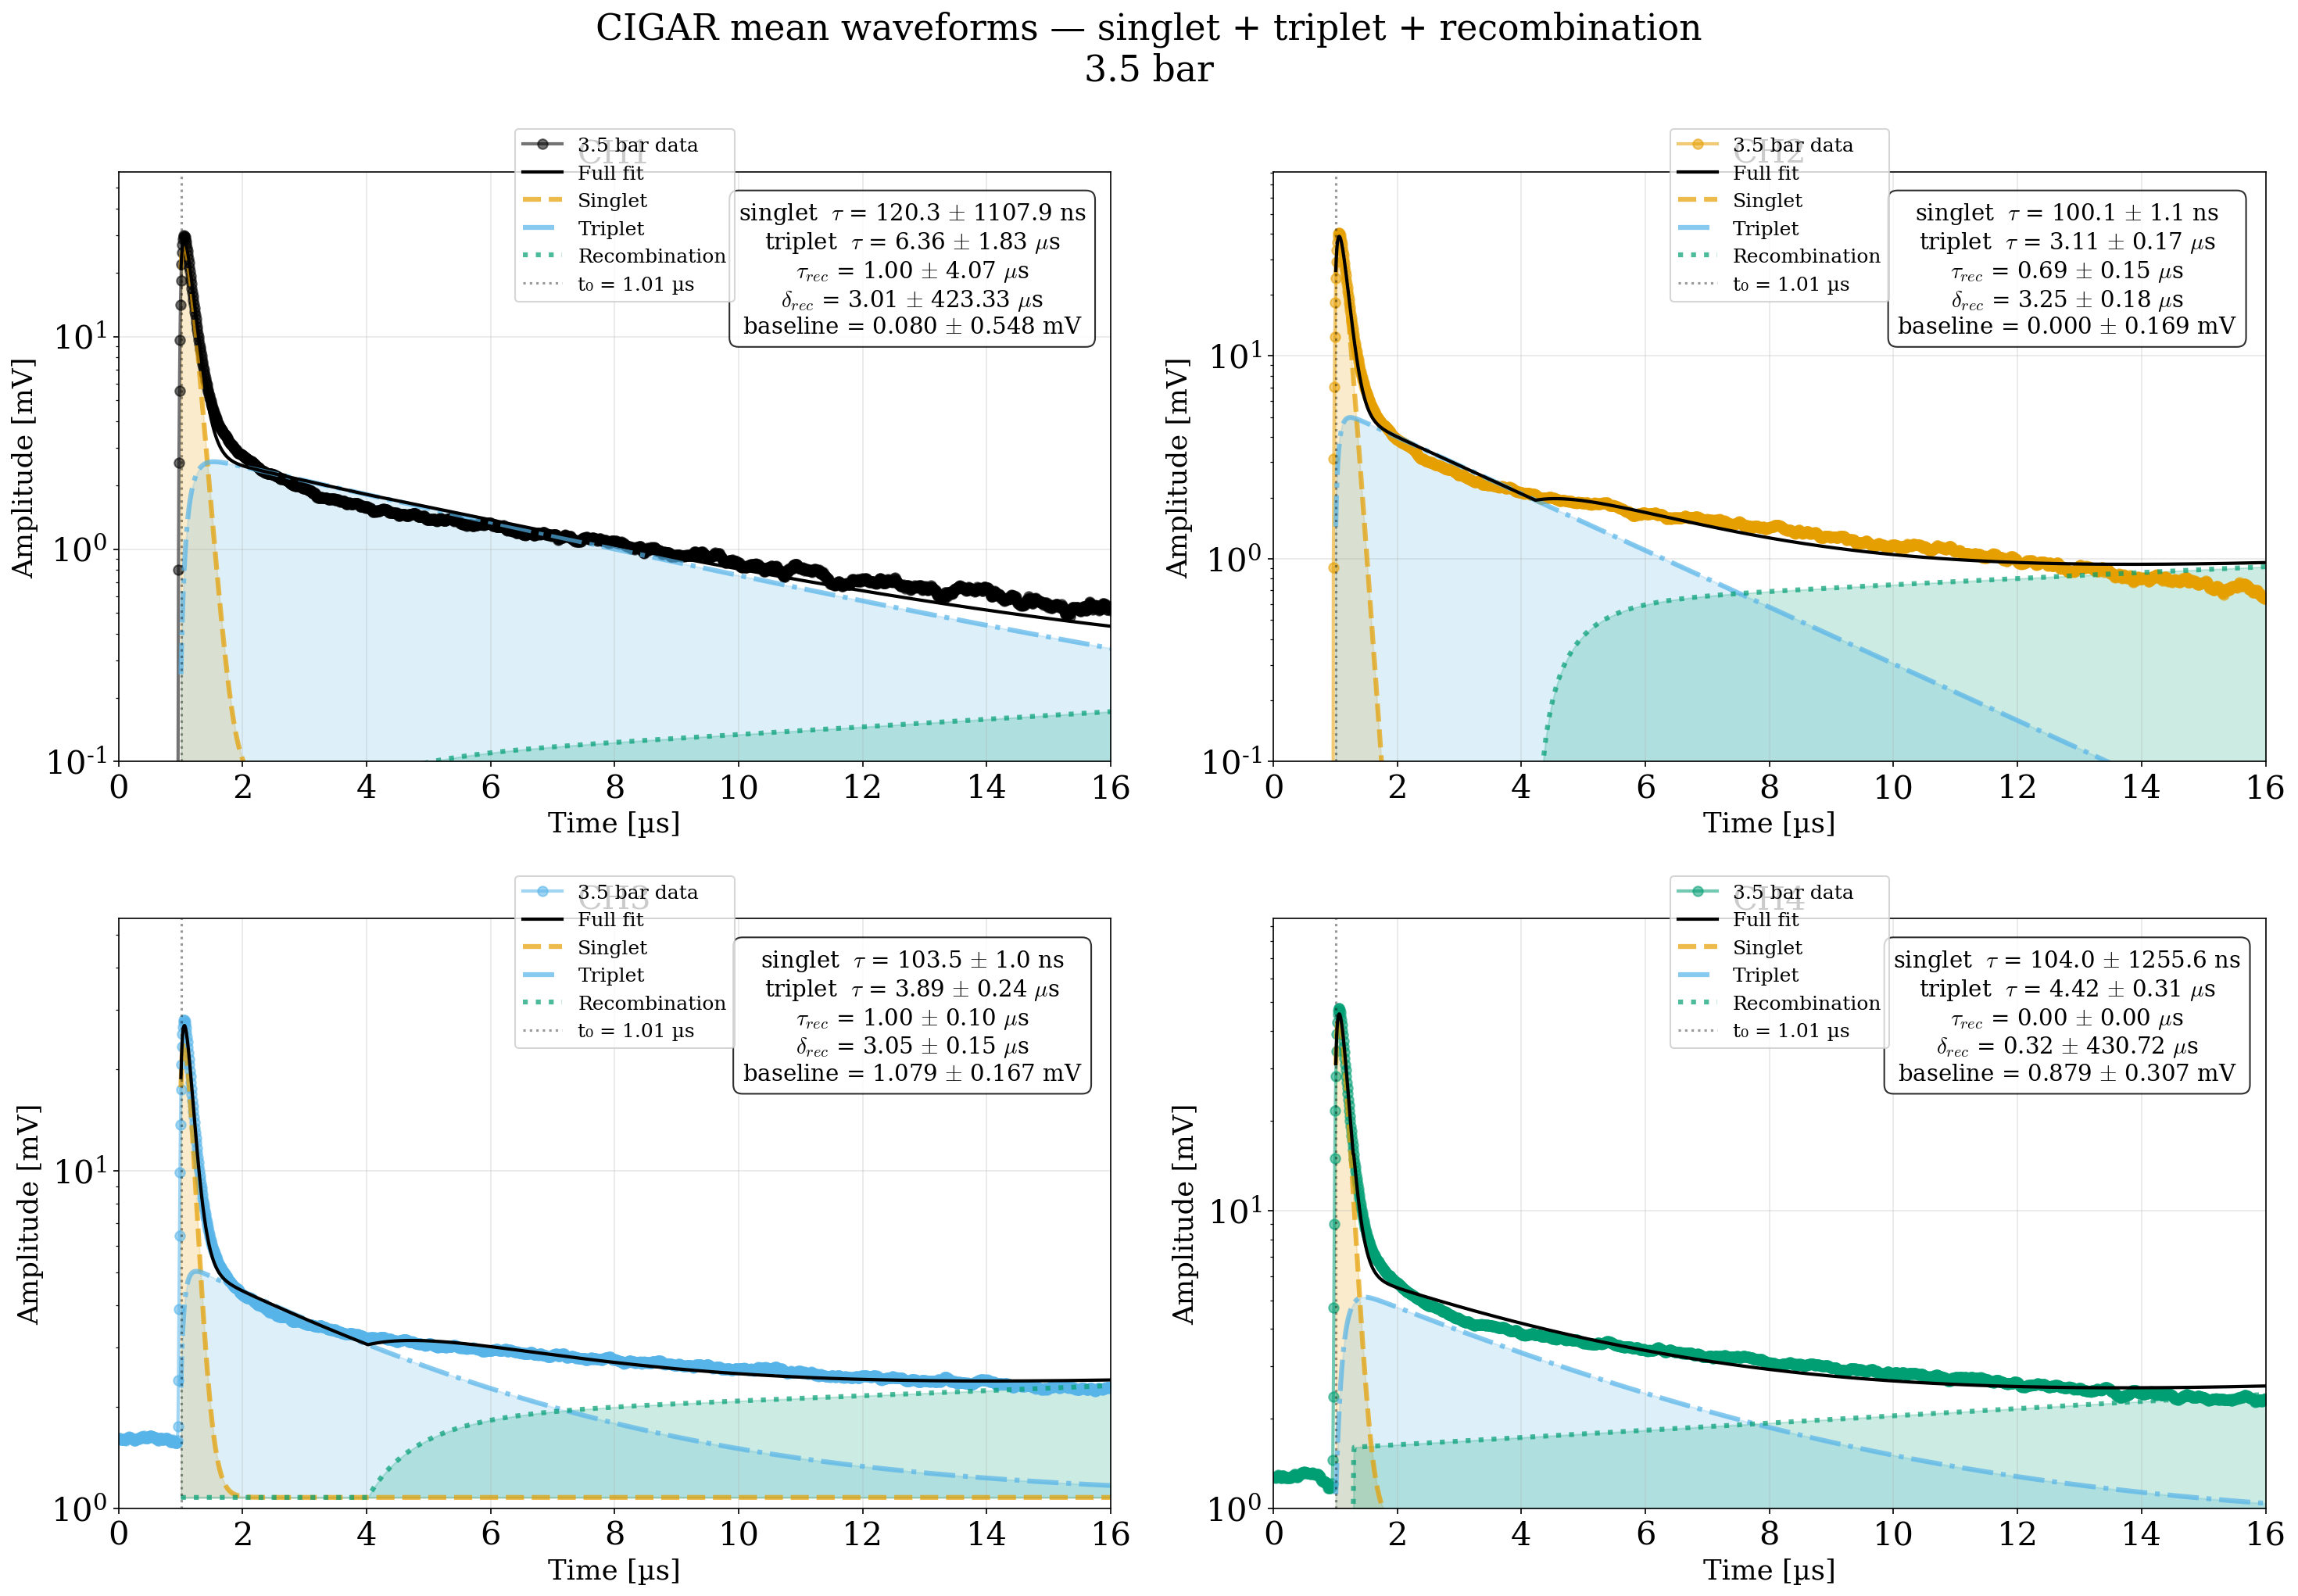


=== CH1  @  3.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.532  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.010  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.005  →  ✓ delta approx valid

=== CH2  @  3.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.639  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.021  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.001  →  ✓ delta approx valid

=== CH3  @  3.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.619  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.016  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.001  →  ✓ delta approx valid

=== CH4  @  3.5 bar ===

SiPM decay 

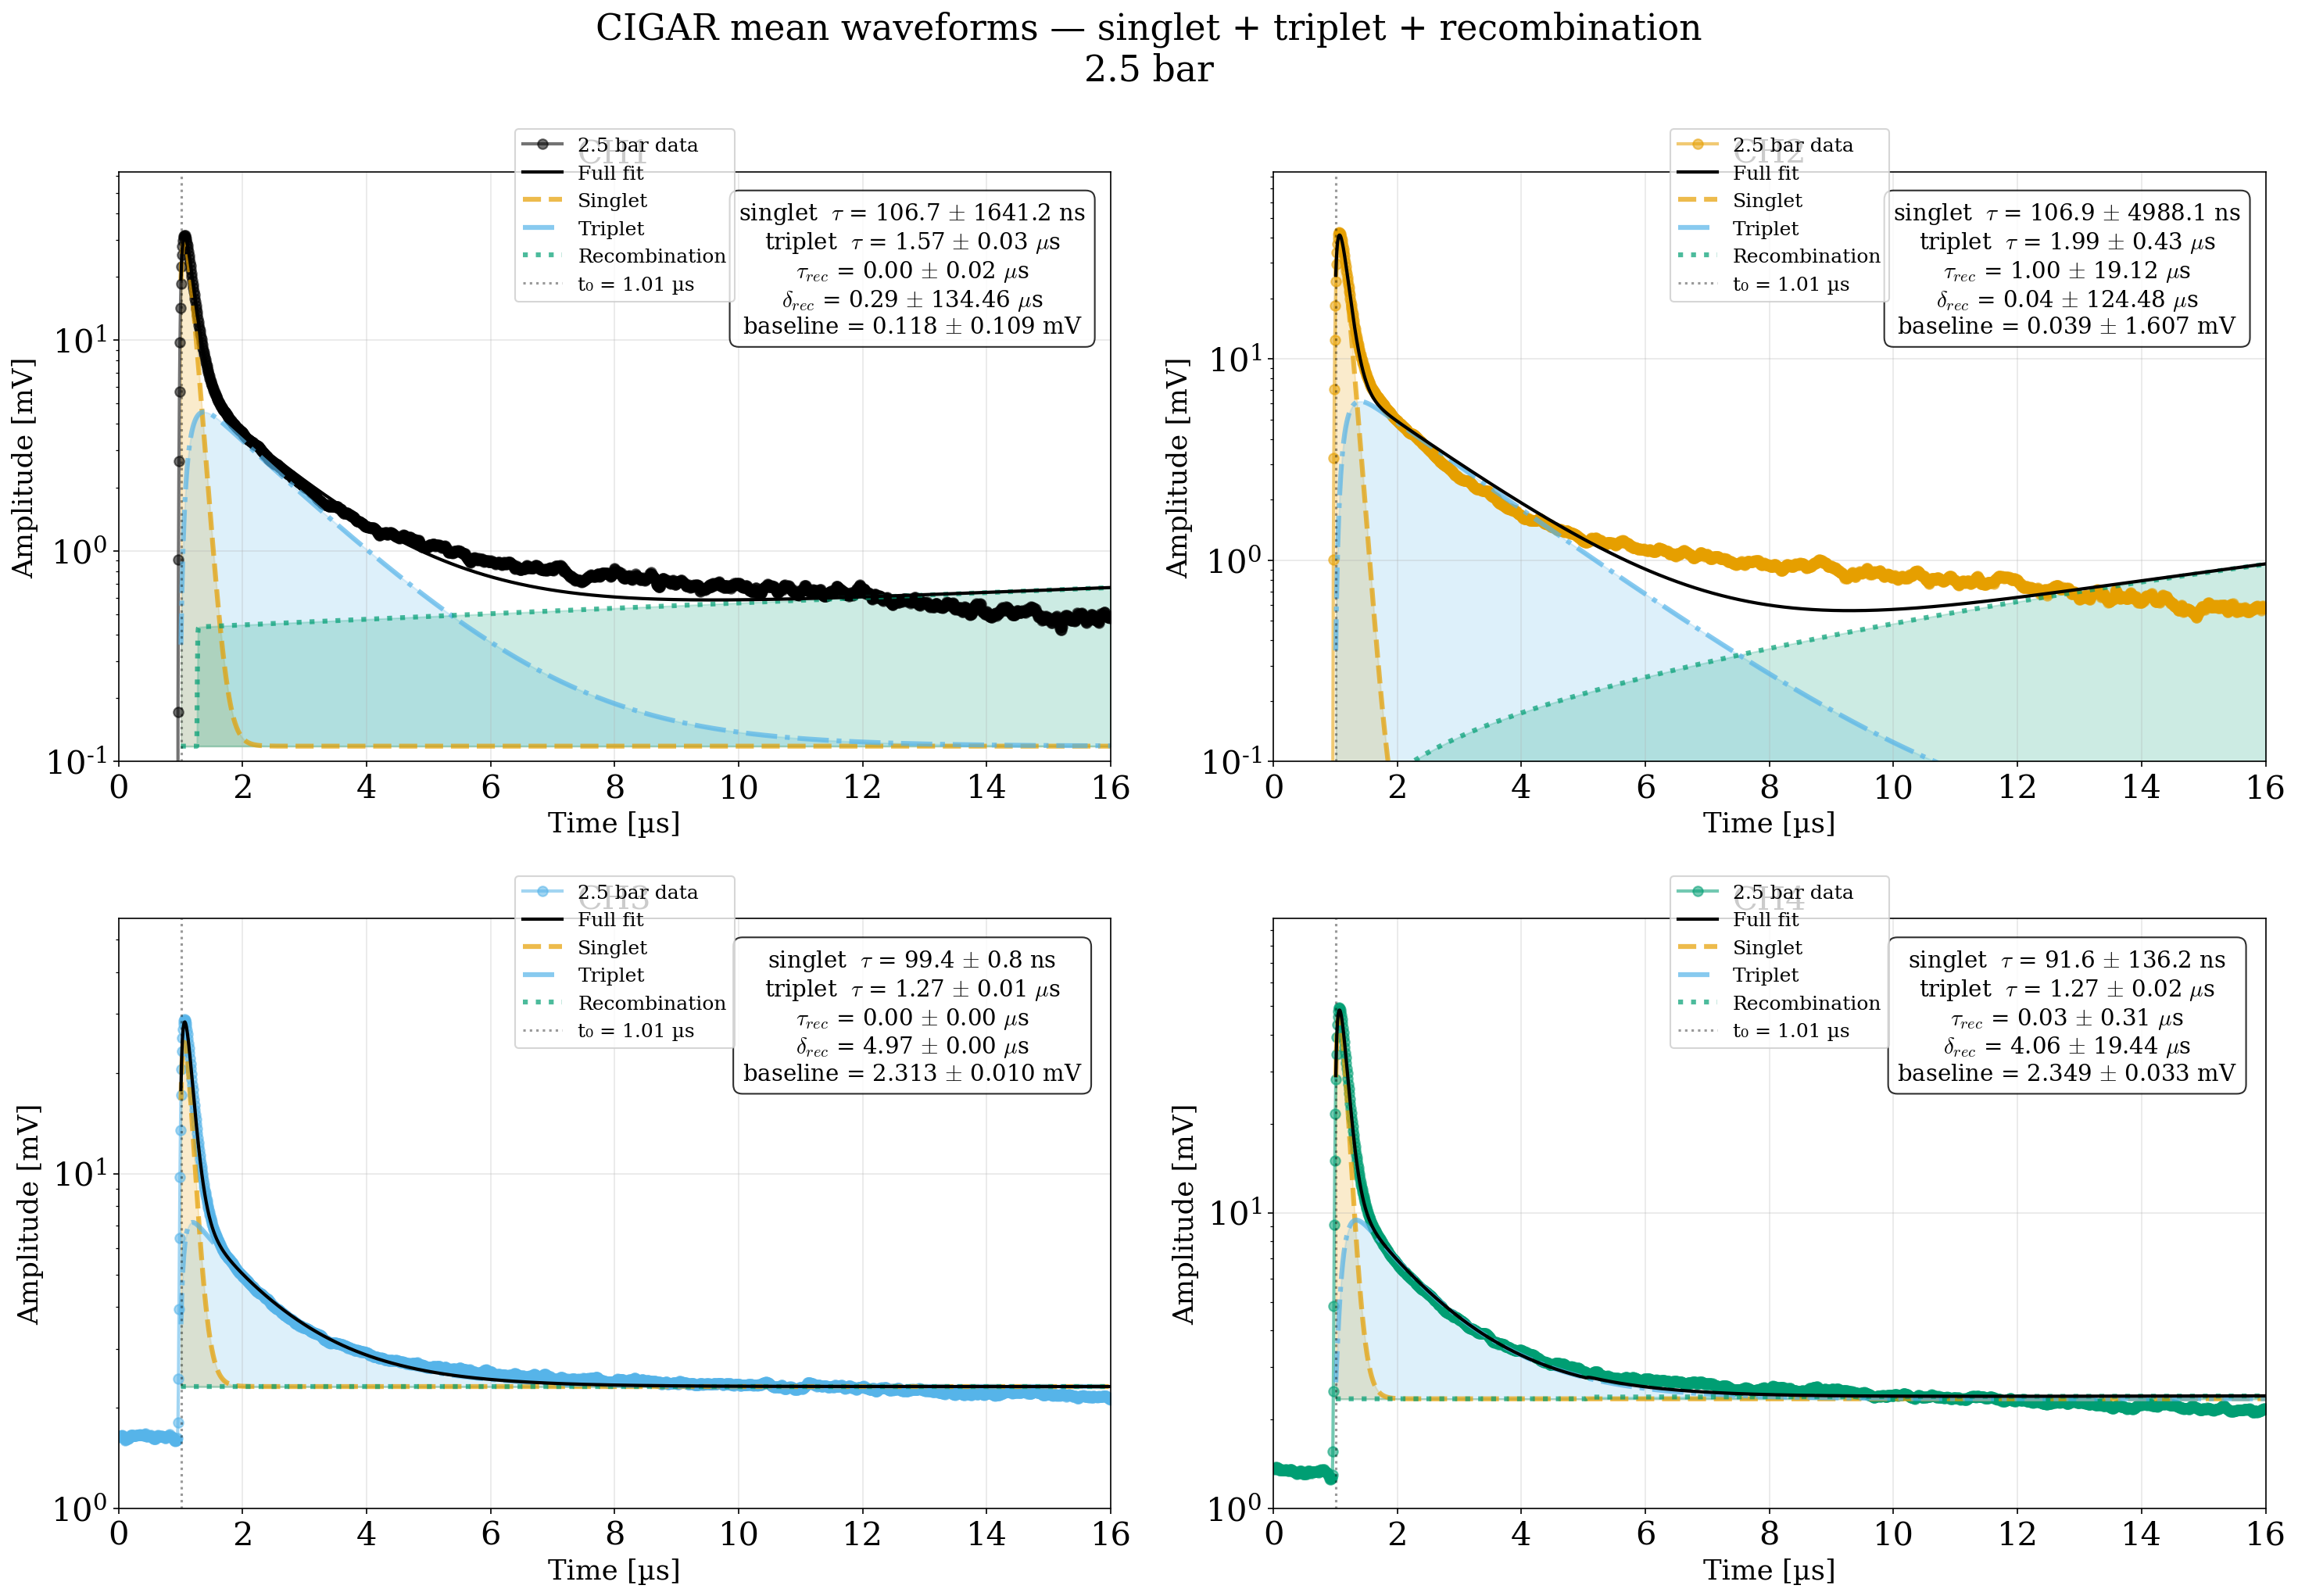


=== CH1  @  2.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.600  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.041  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.001  →  ✓ delta approx valid

=== CH2  @  2.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.599  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.032  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.013  →  ✓ delta approx valid

=== CH3  @  2.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.644  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.050  →  ✗ full convolution needed
  t_sipm / tau_recombination Tr   = 0.001  →  ✓ delta approx valid

=== CH4  @  2.5 bar ===

SiPM d

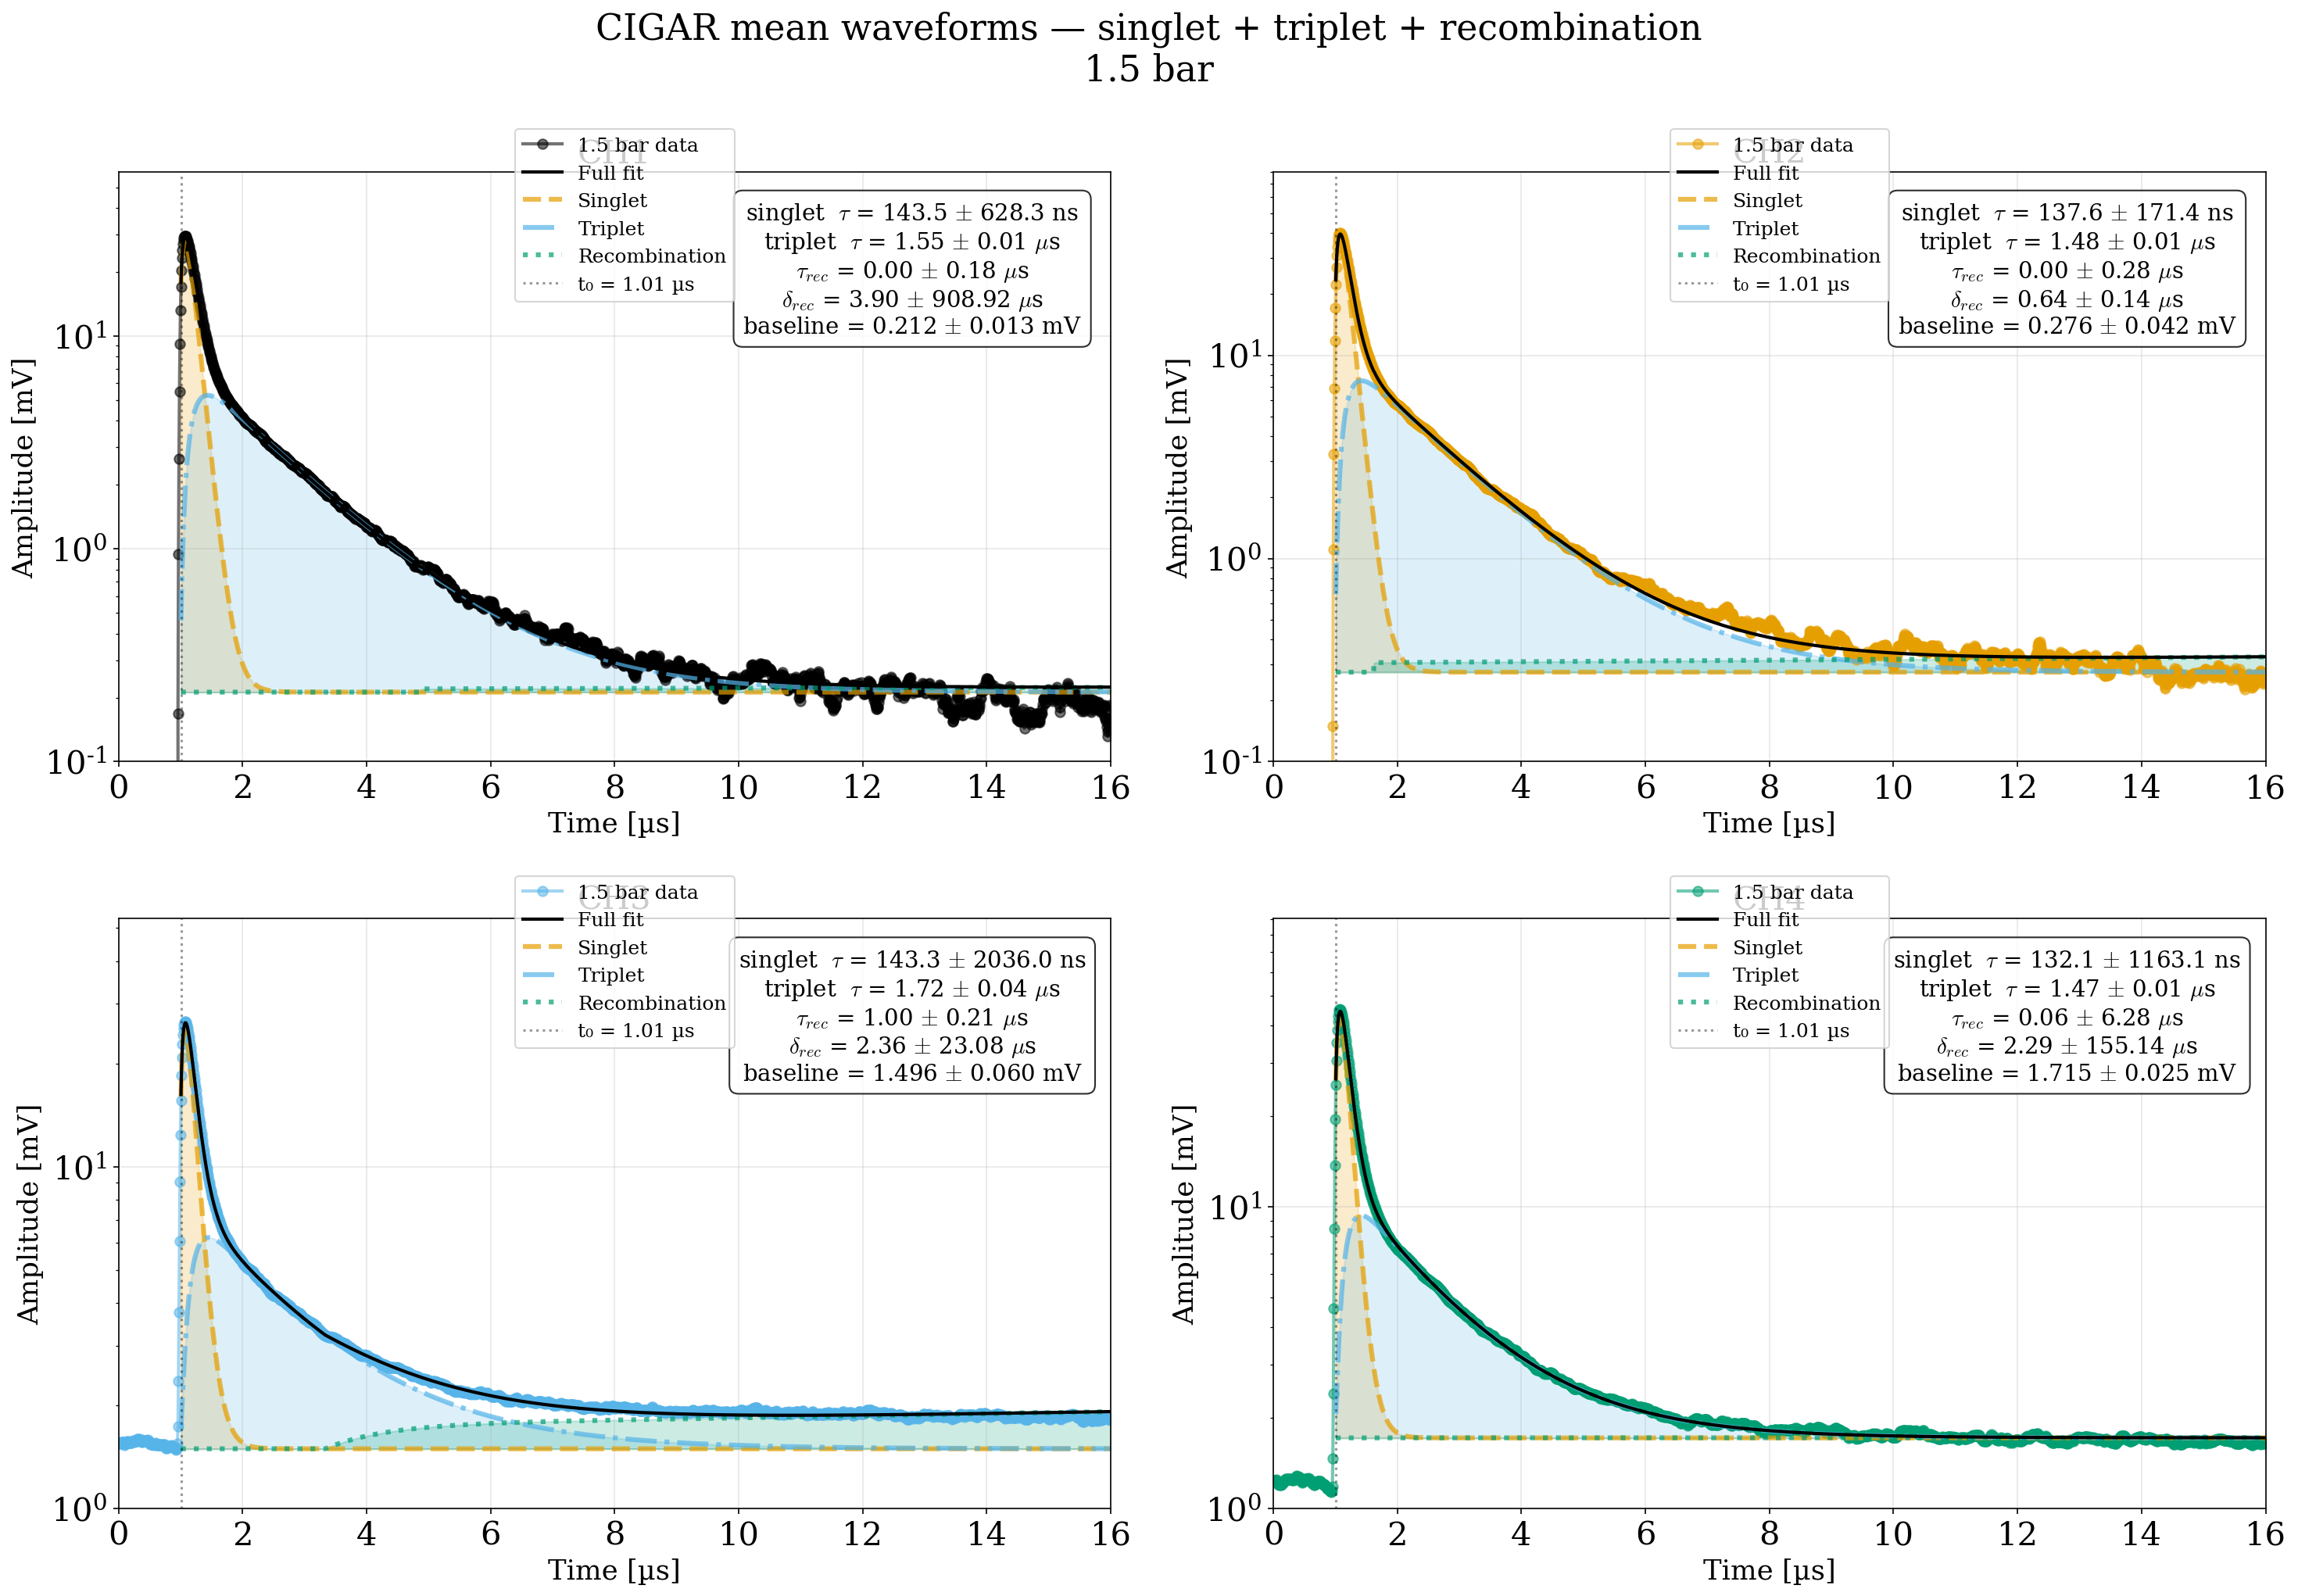


=== CH1  @  1.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.446  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.041  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.001  →  ✓ delta approx valid

=== CH2  @  1.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.465  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.043  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.001  →  ✓ delta approx valid

=== CH3  @  1.5 bar ===

SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet            = 0.447  →  ✗ full convolution needed
  t_sipm / tau_triplet            = 0.037  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr   = 0.001  →  ✓ delta approx valid

=== CH4  @  1.5 bar ===

SiPM decay 

In [19]:
# singlet, triplet, recombination per channel per pressure
singlet_decay, triplet_decay = {}, {}
rec_tau, rec_Tr = {}, {}

prev_cp = None  # warm-start seed from the previous (higher) pressure

for bars, run_name in sorted(runs.items(), reverse=True):   # 8.5 → 1.5 bar
    run = {bars: run_name}

    # build warm-start p0 from previous pressure's result
    p0_warm = None
    if prev_cp is not None:
        p0_warm = {
            f'CH{ch_idx+1}': [
                prev_cp[f'CH{ch_idx+1}']['t0_ar'],
                prev_cp[f'CH{ch_idx+1}']['A_singlet'],
                prev_cp[f'CH{ch_idx+1}']['rise_singlet'],
                prev_cp[f'CH{ch_idx+1}']['tau_singlet'],
                prev_cp[f'CH{ch_idx+1}']['A_triplet'],
                prev_cp[f'CH{ch_idx+1}']['rise_triplet'],
                prev_cp[f'CH{ch_idx+1}']['tau_triplet'],
                prev_cp[f'CH{ch_idx+1}']['A_rec'],
                prev_cp[f'CH{ch_idx+1}']['tau_rec'],
                prev_cp[f'CH{ch_idx+1}']['Tr'],
                prev_cp[f'CH{ch_idx+1}']['delta_rec'],
            ]
            for ch_idx in range(4)
            if f'CH{ch_idx+1}' in prev_cp
        }

    fig, axs_cig, cp = fit_cigar_waveforms(
        run, base,
        pretrigger_sample = 125,
        channels_to_show  = None,
        invert            = True,
        p0_cigar          = p0_warm,
        bounds_cigar      = None,
        colors            = colors,
        font_size         = 20,
        logscale          = True,
    )
    plt.show()

    # timescale validity check for this pressure
    for ch, p in cp.items():
        print(f'\n=== {ch}  @  {bars} bar ===')
        check_timescale_validity(p['tau_singlet'], p['tau_triplet'], p['Tr'])

    # check covariance condition and store results
    for ch in cp:
        cov  = cp[ch]['pcov']
        cond = np.linalg.cond(cov) if not np.any(np.isnan(cov)) else np.inf

        if np.any(np.isnan(cov)):
            print(f'  ✗ [{ch}] {bars} bar — fit failed, errors are NaN')
        elif cond > 1e8:
            print(f'  ⚠ [{ch}] {bars} bar — pcov ill-conditioned '
                  f'(cond={cond:.1e}), errors unreliable')

        if ch not in singlet_decay:
            singlet_decay[ch] = {}
            triplet_decay[ch] = {}
            rec_tau[ch]       = {}
            rec_Tr[ch]        = {}

        singlet_decay[ch][bars] = (cp[ch]['tau_singlet'],
                                   np.sqrt(cov[3, 3]) if not np.isnan(cov[3,3]) else np.nan)
        triplet_decay[ch][bars] = (cp[ch]['tau_triplet'],
                                   np.sqrt(cov[6, 6]) if not np.isnan(cov[6,6]) else np.nan)
        rec_tau[ch][bars]       = (cp[ch]['tau_rec'],
                                   np.sqrt(cov[8, 8]) if not np.isnan(cov[8,8]) else np.nan)
        rec_Tr[ch][bars]        = (cp[ch]['Tr'],
                                   np.sqrt(cov[9, 9]) if not np.isnan(cov[9,9]) else np.nan)

    prev_cp = cp   # pass this fit as warm start to next pressure

print('\nDONE!')

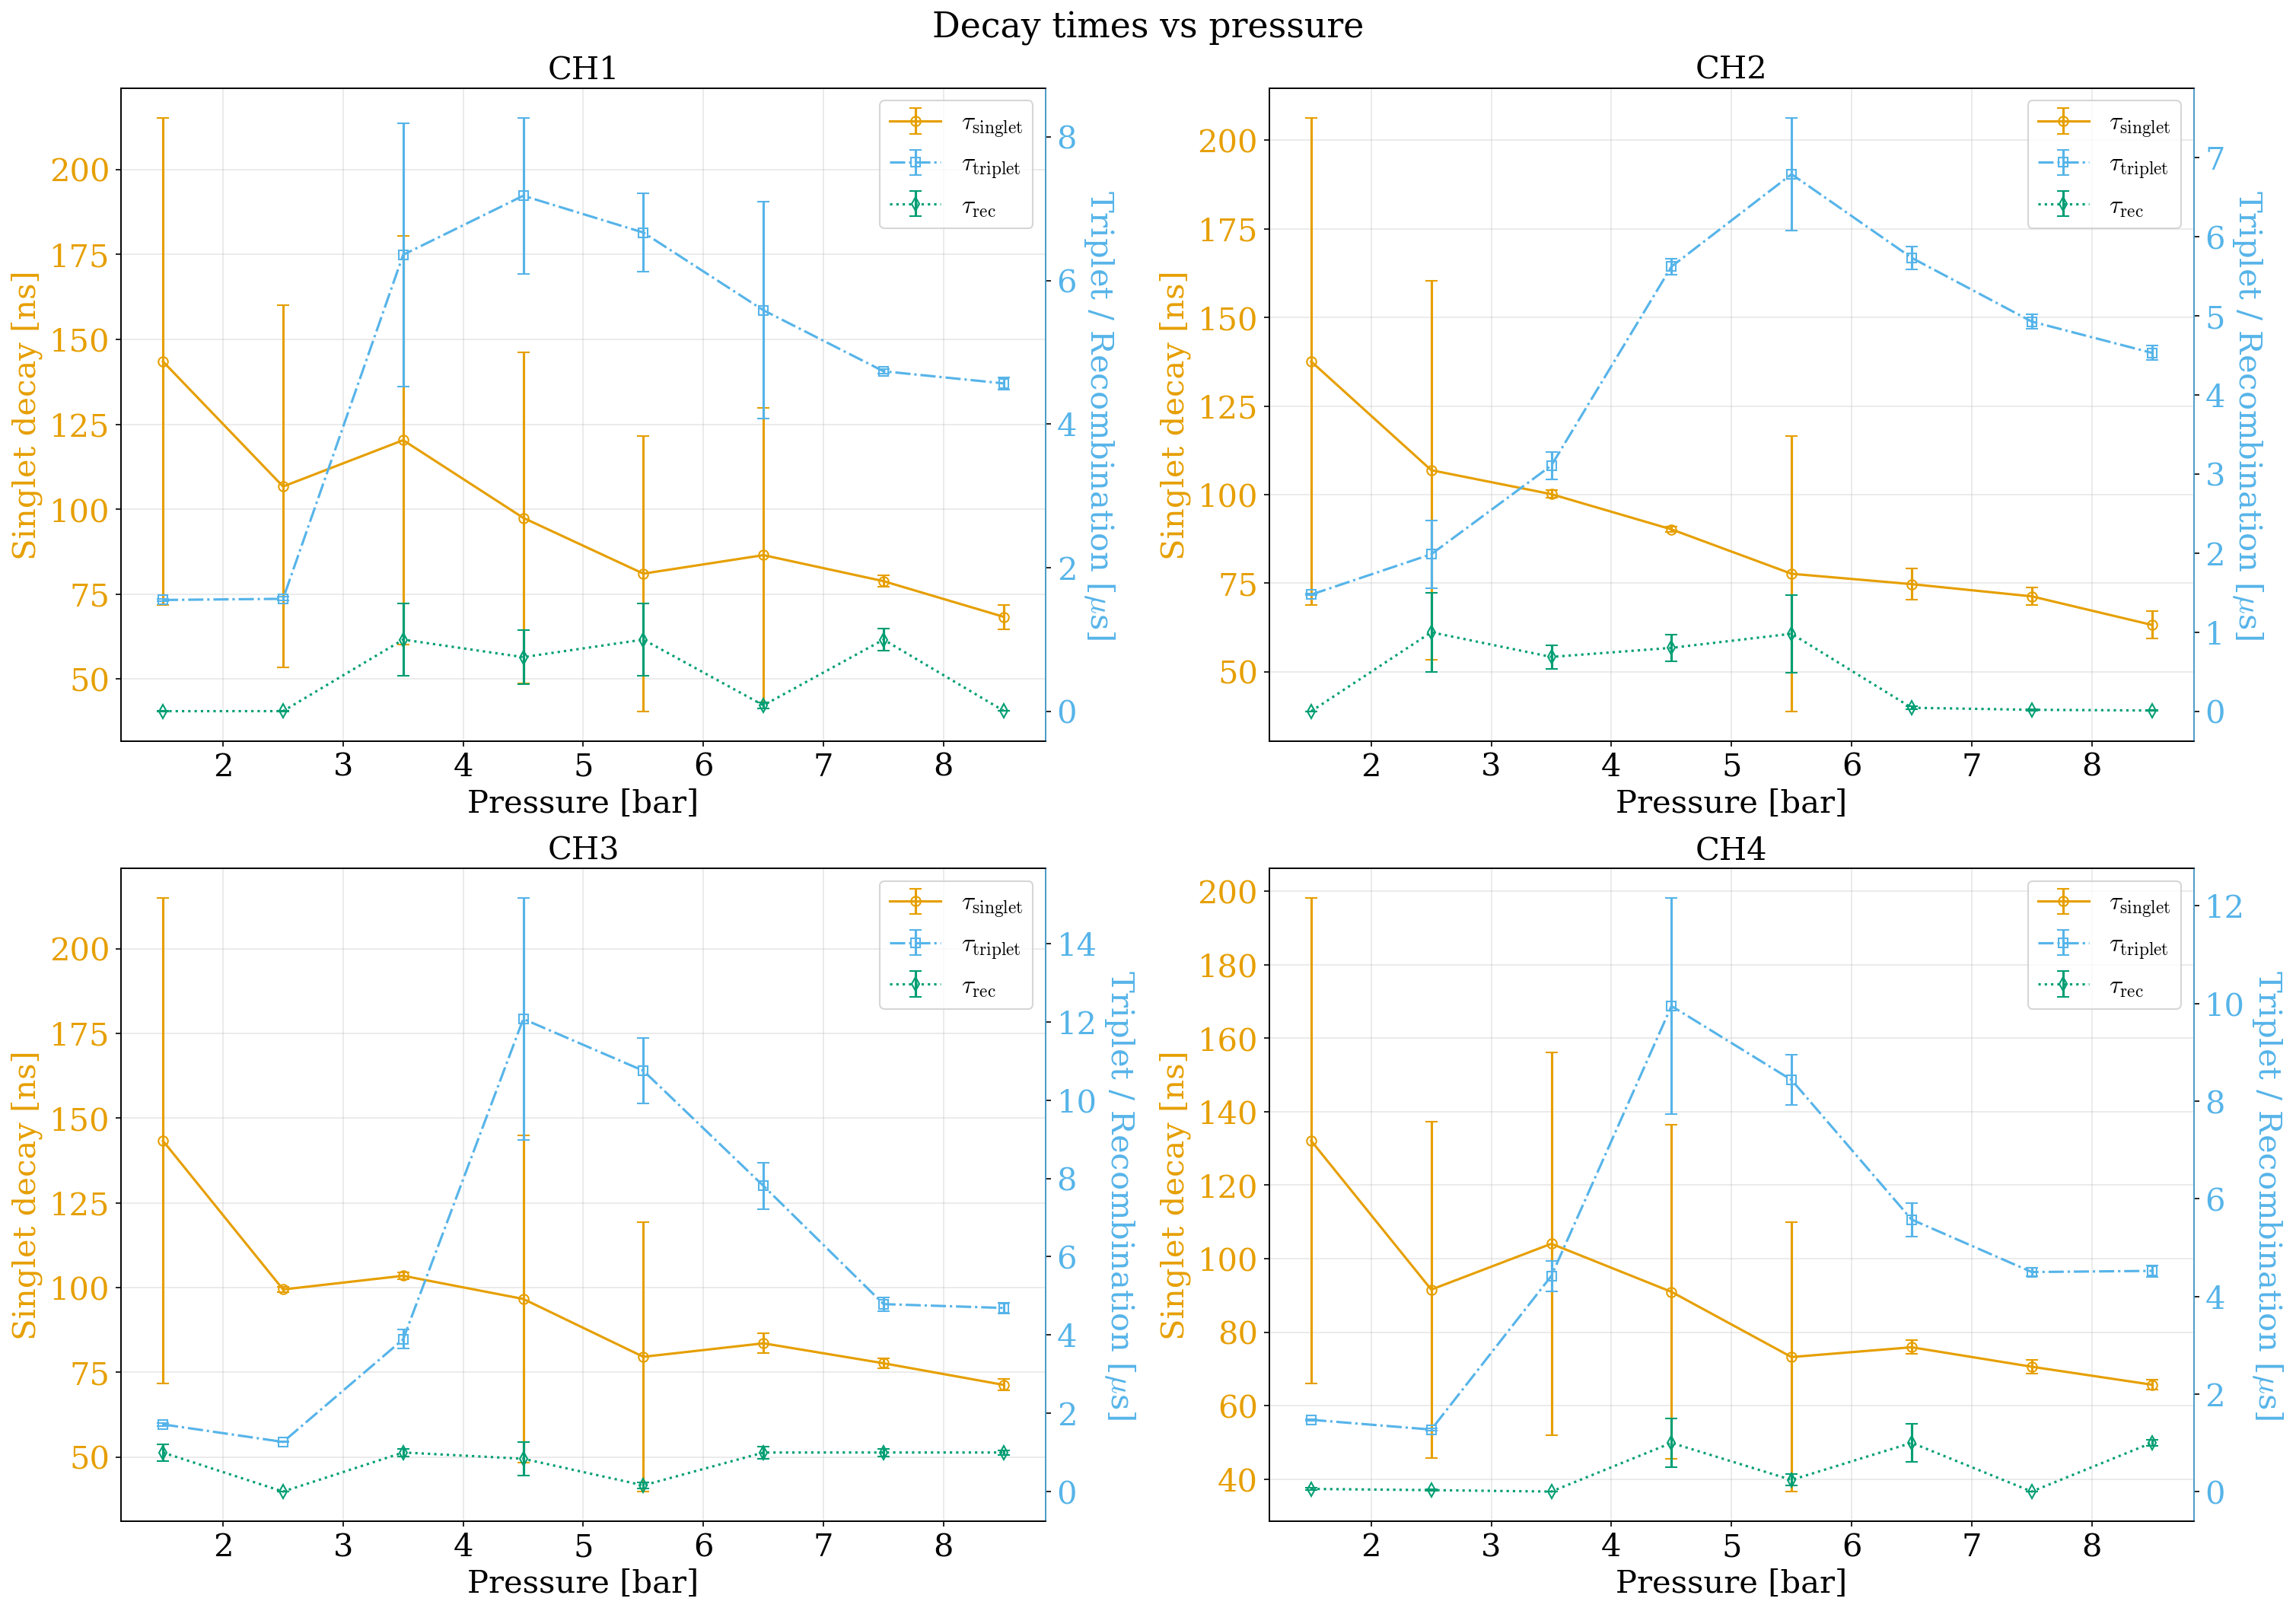

In [20]:
MAX_REL_ERR = 0.5   # cap error bars at 50% of central value for display

fig, axs = plt.subplots(2, 2, figsize=(20, 14), dpi=150, constrained_layout=True)
fig.suptitle('Decay times vs pressure', fontsize=font_size + 2)

# branch colors follow the active palette, same indices as in fit_cigar_waveforms
col_singlet = colors[1]
col_triplet = colors[2]
col_rec     = colors[3]

for ii, ch in enumerate(sorted(singlet_decay.keys())):
    ax  = axs.flat[ii]
    ax2 = ax.twinx()

    bars_list = sorted(singlet_decay[ch].keys())

    tau_singlet  = np.array([singlet_decay[ch][b][0] for b in bars_list]) * 1e9
    err_singlet  = np.array([singlet_decay[ch][b][1] for b in bars_list]) * 1e9
    tau_triplet  = np.array([triplet_decay[ch][b][0] for b in bars_list]) * 1e6
    err_triplet  = np.array([triplet_decay[ch][b][1] for b in bars_list]) * 1e6
    tau_rec_vals = np.array([rec_tau[ch][b][0]       for b in bars_list]) * 1e6
    err_rec_vals = np.array([rec_tau[ch][b][1]       for b in bars_list]) * 1e6

    # cap error bars so one bad pressure does not blow up the axis scale
    err_singlet  = np.minimum(err_singlet,  np.abs(tau_singlet)  * MAX_REL_ERR)
    err_triplet  = np.minimum(err_triplet,  np.abs(tau_triplet)  * MAX_REL_ERR)
    err_rec_vals = np.minimum(err_rec_vals, np.abs(tau_rec_vals) * MAX_REL_ERR)

    ax.errorbar(bars_list, tau_singlet, yerr=err_singlet,
                fmt='o-', color=col_singlet,
                markerfacecolor='none', markeredgecolor=col_singlet,
                label=r'$\tau_\mathrm{singlet}$', capsize=4)

    ax2.errorbar(bars_list, tau_triplet, yerr=err_triplet,
                 fmt='s-.', color=col_triplet,
                 markerfacecolor='none', markeredgecolor=col_triplet,
                 label=r'$\tau_\mathrm{triplet}$', capsize=4)

    ax2.errorbar(bars_list, tau_rec_vals, yerr=err_rec_vals,
                 fmt='d:', color=col_rec,
                 markerfacecolor='none', markeredgecolor=col_rec,
                 label=r'$\tau_\mathrm{rec}$', capsize=4)

    ax.set_title(ch, fontsize=font_size)
    ax.set_xlabel('Pressure [bar]', fontsize=font_size)
    ax.set_ylabel('Singlet decay [ns]', fontsize=font_size, color=col_singlet)
    ax.tick_params(axis='y', labelcolor=col_singlet)

    ax2.set_ylabel(r'Triplet / Recombination [$\mu$s]',
                   fontsize=font_size, rotation=270, labelpad=25)
    ax2.yaxis.label.set_color(col_triplet)
    ax2.tick_params(axis='y', labelcolor=col_triplet)
    ax2.spines['right'].set_color(col_triplet)

    ax.grid(True, alpha=0.3)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              fontsize=font_size * 0.8, loc='upper right')

plt.show()